# TCCT S71 - Blind Topology Transfer Checkpoint

Recovered from the 111-page Wolfram PDF. The original 142 input cell labels are preserved in cell metadata and headings.

Use **Kernel > Restart Kernel and Run All Cells** for a clean run.

## Environment check

In [9]:
<|"WolframVersion" -> $Version, "SystemID" -> $SystemID, "ProcessorCount" -> $ProcessorCount|>

<|WolframVersion -> 15.0.0 for Microsoft Windows (64-bit) (May 26, 2026), 
 
>   SystemID -> Windows-x86-64, ProcessorCount -> 10|>

## Recovered S59-S71 experiment

The cells below follow the execution order recorded in the PDF.

In [14]:
ClearAll["Global`*"];
$HistoryLength=0;
"TCCT CLEAN START"

TCCT CLEAN START

In [17]:
P59[a_, b_, n_Integer, s_Integer]:=
If[
n<=0,
{DirectedEdge[a, b]},
DirectedEdge@@@Partition[
Join[{a}, Range[s, s+n-1],{b}],
2, 1
]
];
A59[t_, fan_Integer, s_Integer]:=
Module[{p1, p2, ls},
p1=s+1;
p2=s+2;
ls=Range[s+3, s+2+fan];
Join[
{
DirectedEdge[p2, p1],
DirectedEdge[p1, t]
},
Table[
DirectedEdge[ls[[i]], p2],
{i, Length[ls]}
]
]
];
T59[d_Integer, r_String , a_Integer, seed_Integer]:=
Module[
{bb, K, c, v, q, e, f= {}, ib, m, safe, u, dum, r1, r2,
wrong, main, perm, anc, i},
bb=1000000000*seed;
K=bb+1;
c=Table[bb+100+i,{i, 4}];
v=Table[bb+200+i,{i, 4}];
q=Table[bb+300+i,{i, 4}];
e=Flatten[
Table[
{
DirectedEdge[K, c[[i]]],
DirectedEdge[c[[i]], v[[i]]]
},
{i, 4}
],
1
];
Do[
ib=bb+20000000*i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i, 4]]];
main=Join[
P59[q[[i]], r1, d, ib+1000000],
P59[q[[i]], r2, d, ib+2000000],
{
DirectedEdge[r1, m],
DirectedEdge[r2, m]
},
P59[q[[i]], safe, d+1, ib+3000000]
];
perm=
If[
r==="Continue",
{
DirectedEdge[m, c[[i]]],
DirectedEdge[safe, dum],
DirectedEdge[u, wrong]
},
{
DirectedEdge[m, wrong],
DirectedEdge[safe, c[[i]]],
DirectedEdge[u, dum]
}
];
anc=Join[
A59[m, i, bb+970000000+10000*i],
A59[c[[i]], i, bb+980000000+10000*i]
];
e=Join[e, main, perm, anc];
AppendTo[f, m],
{i, 4}
];
{{Union[e], q, K, v, c, f}, a}
];
Case59[d_Integer, a_Integer, r_String]:=
T59[d,r,a,59000000+100*d+a] ;

In [21]:
h59={
Head[Case59[2, 1, "Continue"]],
Length[Case59[2, 1, "Continue"]],
Length[Case59[2, 1, "Continue"][[1]]],
Length[Case59[2, 1, "Continue"][[1, 1]]],
Length[Case59[2, 1, "Stop"][[1, 1]]]
};
h59

{List, 2, 6, 104, 104}

In [23]:
rw60= {-9, 6,-2,-2, 4, 2,-2, 6, 0};
Pack60[c_List]:=
Module[
{x=c[[1]], a=c[[2]], e, v, pos, gi, go,
pa, ch, id, od, pin, pout, cin, cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[
v,
Range[Length[v]]
];
gi=GroupBy[
Cases[
e,
DirectedEdge[u_, w_ ]:>{w, u}
],
First->Last
];
go=GroupBy[
Cases[
e,
DirectedEdge[u_, w_ ]:>{u, w}
],
First->Last
];
pa=(Lookup[pos, Lookup[gi,#,{}]]&)/@v;
ch= (Lookup[pos, Lookup[go,#,{}]]&) /@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout= (Total[od[[#]]]&) /@pa;
cin=(Total[id[[#]]]&)/@ch;
cout= (Total[od[[#]]]&) /@ch;
{
pa, id, od,
Lookup[pos, x[[2, a]]],
Lookup[pos, x[[5]]],
a,
Length[v],
pin, pout, cin, cout, v
}
];

In [25]:
p60=Pack60[
Case59[2, 1, "Continue"]
];
{
Length[p60],
IntegerQ[p60[[4]]],
Length[p60[[1]]],
p60[[7]],
Length[p60[[12]]]
}

{12, True, 101, 101, 101}

In [27]:
SigLevels61[c_List , rmax_Integer]:=
Module[
{p, pa, id, od, n, ch, cur, nxt, levs, j, k, u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{}, n];
Do[
Do[
If[
u>0,
ch[[u]]=Append[ch[[u]], j]
],
{u, pa[[j]]}
],
{j, n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id, od}]
];
levs= {cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur, j],
Sort[Lookup[cur, pa[[j]]]],
Sort[Lookup[cur, ch[[j]]]]
},
{j, n}
]
];
AppendTo[levs, nxt];
cur=nxt,
{k, rmax}
];
levs
];

In [28]:
s61=SigLevels61[
Case59[2, 1, "Continue"],
2
];
{
Length[s61],
AssociationQ[s61[[1]]],
AssociationQ[s61[[2]]],
AssociationQ[s61[[3]]]
}

{3, True, True, True}

In [30]:
Reject61[c_List]:=
Module[
{p, pa, id, od, q, n, pin, pout, cin, cout,
h, z, h2, nz, j, k, aps, ap, pz, o, zv,
rf, rd, dd, pg, allow, active, rej= {}},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
h=ConstantArray[0, n];
z=ConstantArray[0, n];
h[[q]]=1;
For[
k=1,
k<=64,
k++,
h2=ConstantArray[0, n];
nz=ConstantArray[0, n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u, u>0 && h[[u]] ==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv= {0, 1, 2, 1, 3, 1, 3, 1}[
[1+2*pz+o]
];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2*cout[[j]];
pg=od[[j]]+2*Boole[zv>0] -zv;
If[
rd>0 && dd<=0,
AppendTo[rej,{k, j}]
];
allow=
If[
rd>0,
dd>0,
pg>0
];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j, n}
];
h=h2;
z=nz;
If[
active==0,
Break[]
]
];
rej
];
DecisionStates64[c_List , r_Integer]:=
Module[{rej, lev},
rej=Reject61[c];
If[
Length[rej] ==0,
Return[{}]
];
lev=SigLevels61[c, r][[r+1]];
DeleteDuplicates[
Lookup[
lev,
rej[[All, 2]]
]
]
];

In [32]:
{
Length[
DecisionStates64[
Case59[2, 1, "Continue"],
2
]
],
Length[
DecisionStates64[
Case59[2, 1, "Stop"],
2
]
]
}

{1, 1}

In [33]:
stateDict62= {};
Do[
stateDict62=Join[
stateDict62,
DecisionStates64[
Case59[d, a, "Continue"],
2
],
DecisionStates64[
Case59[d, a, "Stop"],
2
]
],
{d,{2, 5}},
{a, 1, 4}
];
stateDict62=
DeleteDuplicates[
stateDict62
];
Length[stateDict62]

8

In [37]:
ClearAll[Prep62];
Prep62[c_List]:=Module[
{p, lev, n, codes, pos, j},
p=Pack60[c];
n=p[[7]];
lev=SigLevels61[c, 2][[3]];
codes=Table[
pos=FirstPosition[
stateDict62,
Lookup[lev, j],
Missing["NF"]
];
If[
MissingQ[pos],
0,
First[pos]
],
{j, n}
];
{p, codes}
];

In [39]:
t62=Prep62[
Case59[2, 1, "Continue"]
];
{
Length[t62],
Length[t62[[2]]],
t62[[1, 7]],
Min[t62[[2]]],
Max[t62[[2]]]
}

{2, 101, 101, 0, 7}

In [41]:
ClearAll[Run62];
Run62[x_List , pol_List , ret_Integer: 0]:=
Module[
{p, rc, pa, id, od, q, ca, ans, n, pin, pout, cin, cout,
h, z, h2, nz, arr, j, k, s, pp, ap, pz, o, zv, rf, rd,
dd, pg, allow, active, reached, pass, code, dc= {}},
p=x[[1]];
rc=x[[2]];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
ca=p[[5]];
ans=p[[6]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
h=ConstantArray[0, n];
z=ConstantArray[0, n];
arr=ConstantArray[-1, n];
h[[q]]=1;
arr[[q]]=0;
For[
k=1,
k<=64,
k++,
h2=ConstantArray[0, n];
nz=ConstantArray[0, n];
active=0;
Do[
ap=0;
pz=0;
Do[
pp=pa[[j, s]];
If[
IntegerQ[pp]&& pp>0 && h[[pp]] ==1,
ap++;
If[z[[pp]]>pz, pz=z[[pp]]]
],
{s, 1, Length[pa[[j]]]}
];
If[
ap>0,
o=Boole[ap>1];
zv= {0, 1, 2, 1, 3, 1, 3, 1}[
[1+2*pz+o]
];
nz[[j]]=zv;
If[
arr[[j]]<0,
arr[[j]]=k
];
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2*cout[[j]];
pg=od[[j]]+2*Boole[zv>0] -zv;
code=rc[[j]];
If[
rd>0 && dd<=0,
AppendTo[dc, code]
];
allow=
If[
rd>0 && dd<=0 &&
IntegerQ[code]&&
code>0 &&
MemberQ[pol, code],
pg>0,
If[
rd>0,
dd>0,
pg>0
]
];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j, n}
];
h=h2;
z=nz;
If[
active==0,
Break[]
]
];
reached=Select[
Range[4],
Function[u,
arr[[ca[[u]]]] >=0
]
];
pass=Boole[
Length[reached]==1 &&
First[reached]==ans
];
If[
ret==1,
{pass, DeleteDuplicates[dc]},
pass
]
];

In [43]:
x62=Prep62[
Case59[2, 1, "Continue"]
];
{
Run62[x62,{}],
Run62[x62, Range[8]],
Run62[x62,{1, 3, 5, 7}, 1]
}

{0, 1, {1, {1, 0}}}

In [45]:
trainSpec62=Tuples[
{
{2, 5},
Range[4],
{"Continue", "Stop"}
}
];
Length[trainSpec62]

16

In [47]:
train62=
(Prep62[
Case59@@ #
]&) /@trainSpec62;
{
Length[train62],
And@@(
Length[#]==2 &/@train62
)
}

{16, True}

In [49]:
policies62=Subsets[
Range[8]
];
Length[policies62]

256

In [51]:
polChunks62=Partition[
policies62,
64
];
Length/@polChunks62

{64, 64, 64, 64}

In [53]:
ClearAll[ScorePolicy62];
ScorePolicy62[pol_List]:=
Total[
Run62[#, pol]&/@train62
];

In [55]:
{
ScorePolicy62[{}],
ScorePolicy62[{1}],
ScorePolicy62[{1, 3, 5, 7}]
}

{8, 10, 16}

In [56]:
sc62A=ScorePolicy62/@polChunks62[[1]];
{
Length[sc62A],
Min[sc62A],
Max[sc62A]
}

{64, 4, 14}

In [58]:
sc62B=ScorePolicy62/@polChunks62[[2]];
{
Length[sc62B],
Min[sc62B],
Max[sc62B]
}

{64, 2, 16}

In [60]:
sc62C=ScorePolicy62/@polChunks62[[3]];
{
Length[sc62C],
Min[sc62C],
Max[sc62C]
}

{64, 0, 14}

In [62]:
sc62D=ScorePolicy62/@polChunks62[[4]];
{
Length[sc62D],
Min[sc62D],
Max[sc62D]
}

{64, 2, 12}

In [64]:
scores62=Join[
sc62A,
sc62B,
sc62C,
sc62D
];
bestScore62=Max[scores62];
perfectPolicies62=Pick[
policies62,
scores62,
bestScore62
];
{
Length[scores62],
bestScore62,
Length[perfectPolicies62],
perfectPolicies62
}

{256, 16, 1, {{1, 3, 5, 7}}}

In [68]:
best62=First[
perfectPolicies62
];
best62

{1, 3, 5, 7}

In [70]:
heldSpec62=Tuples[
{
{9, 15},
Range[4],
{"Continue", "Stop"}
}
];
held62=
(Prep62[
Case59@@ #
]&) /@heldSpec62;
{
Length[held62],
Total[
Run62[#, best62]&/@held62
]
}

{16, 16}

In [73]:
cert62=<|
"Stage"->"S62",
"Radius"->2,
"StateTypes"->Length[stateDict62],
"TrainDepths"->{2, 5},
"HeldoutDepths"->{9, 15},
"PoliciesTested"->Length[policies62],
"BestTrainPassed"->bestScore62,
"PerfectPolicies"->Length[perfectPolicies62],
"BestPolicy"->best62,
"HeldoutPassed"->Total[
Run62[#, best62]&/@held62
],
"HeldoutCases"->Length[held62]
|>;
Dataset[{cert62}]

Dataset[{<|Stage -> S62, Radius -> 2, StateTypes -> 8, TrainDepths -> {2, 5}, 
 
>     HeldoutDepths -> {9, 15}, PoliciesTested -> 256, BestTrainPassed -> 16, 
 
>     PerfectPolicies -> 1, BestPolicy -> {1, 3, 5, 7}, HeldoutPassed -> 16, 
 
>     HeldoutCases -> 16|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Radius, 
 
>      StateTypes, TrainDepths, HeldoutDepths, PoliciesTested, BestTrainPassed, 
 
>      PerfectPolicies, BestPolicy, HeldoutPassed, HeldoutCases}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 1], <||>]

In [75]:
ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

In [79]:
h63={
Head[Case63["ChainIn", 2, 1, "Continue"]],
Head[Case63["SharedMerge", 2, 1, "Continue"]],
Length[Case63["ChainIn", 2, 1, "Continue"]],
Length[Case63["SharedMerge", 2, 1, "Continue"]],
Length[Case63["ChainIn", 2, 1, "Continue"][[1]]],
Length[Case63["SharedMerge", 2, 1, "Continue"][[1]]]
};
h63

{List, List, 2, 2, 6, 6}

In [81]:
spec63=Tuples[
{
{2, 5, 9, 15},
Range[4],
{"Continue", "Stop"}
}
];
Length[spec63]

32

In [83]:
chain63=
(Prep62[
Case63[
"ChainIn",
#[[1]],
#[[2]],
#[[3]]
]
]&)/@spec63;
{
Length[chain63],
And@@(Length[#]==2 &/@chain63)
}

{32, True}

Dataset[{<|Stage -> S63, Grammar -> ChainIn, Cases -> 32, BaselinePassed -> 16, 
 
>     FrozenPolicyPassed -> 32, FrozenPolicy -> {1, 3, 5, 7}, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, 
 
>      Cases, BaselinePassed, FrozenPolicyPassed, FrozenPolicy, Retraining, PolicySearch}
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
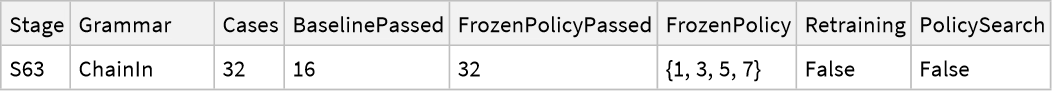

In [85]:
resultChain63=<|
"Stage"->"S63",
"Grammar"->"ChainIn",
"Cases"->Length[chain63],
"BaselinePassed"->Total[
Run62[#,{}]&/@chain63
],
"FrozenPolicyPassed"->Total[
Run62[#, best62]&/@chain63
],
"FrozenPolicy"->best62,
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{resultChain63}]

In [87]:
chainByDepth63=Table[
Module[{idx, z},
idx=Flatten@Position[
spec63,
{x_,_,_} /; x===d
];
z=chain63[[idx]];
<|
"Depth"->d,
"Cases"->Length[z],
"BaselinePassed"->Total[
Run62[#,{}]&/@z
],
"FrozenPassed"->Total[
Run62[#, best62]&/@z
]
|>
],
{d,{2, 5, 9, 15}}
];
Dataset[chainByDepth63]

Dataset[{<|Depth -> 2, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 5, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 9, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 15, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Cases, BaselinePassed, FrozenPassed}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 4], <||>]

In [89]:
merge63=
(Prep62[
Case63[
"SharedMerge",
#[[1]],
#[[2]],
#[[3]]
]
]&) /@spec63;
{
Length[merge63],
And@@ (Length[#]==2 &/@merge63)
}

{32, True}

Dataset[{<|Stage -> S63, Grammar -> SharedMerge, Cases -> 32, BaselinePassed -> 16, 
 
>     FrozenPolicyPassed -> 16, FrozenPolicy -> {1, 3, 5, 7}, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, 
 
>      Cases, BaselinePassed, FrozenPolicyPassed, FrozenPolicy, Retraining, PolicySearch}
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
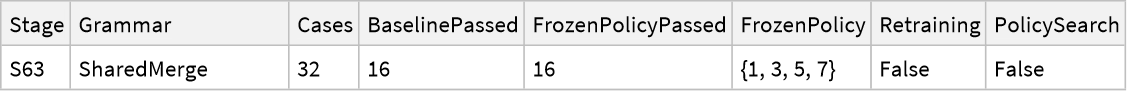

In [91]:
resultMerge63=<|
"Stage"->"S63",
"Grammar"->"SharedMerge",
"Cases"->Length[merge63],
"BaselinePassed"->Total[
Run62[#,{}]&/@merge63
],
"FrozenPolicyPassed"->Total[
Run62[#, best62]&/@merge63
],
"FrozenPolicy"->best62,
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{resultMerge63}]

In [93]:
mergeDetail63=Flatten[
Table[
Module[{idx, z},
idx=Flatten@Position[
spec63,
{x_,_, y_ } /; x===d && y===t
];
z=merge63[[idx]];
<|
"Depth"->d,
"Target"->t,
"Cases"->Length[z],
"BaselinePassed"->Total[
Run62[#,{}]&/@z
],
"FrozenPassed"->Total[
Run62[#, best62]&/@z
]
|>
],
{d,{2, 5, 9, 15}},
{t,{"Continue", "Stop"}}
],
1
];
Dataset[mergeDetail63]

Dataset[{<|Depth -> 2, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 2, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 5, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 5, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 9, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 9, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 15, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 15, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Target, Cases, BaselinePassed, 
 
>      FrozenPassed}, {TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 8]
 
>    , <||>]

Dataset[{<|Stage -> S63, FrozenPolicy -> {1, 3, 5, 7}, ChainInCases -> 32, 
 
>     ChainInBaseline -> 16, ChainInFrozen -> 32, SharedMergeCases -> 32, 
 
>     SharedMergeBaseline -> 16, SharedMergeFrozen -> 16, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, 
 
>      FrozenPolicy, ChainInCases, ChainInBaseline, ChainInFrozen, SharedMergeCases, 
 
>      SharedMergeBaseline, SharedMergeFrozen, Retraining, PolicySearch}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
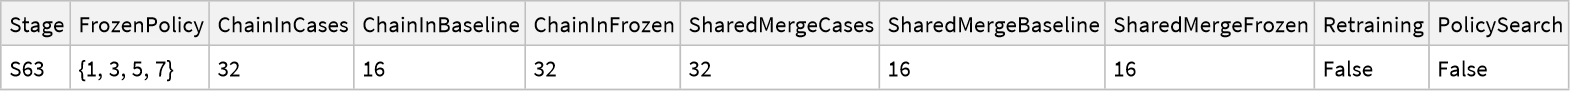

In [95]:
cert63=<|
"Stage"->"S63",
"FrozenPolicy"->best62,
"ChainInCases"->Length[chain63],
"ChainInBaseline"->Total[
Run62[#,{}]&/@chain63
],
"ChainInFrozen"->Total[
Run62[#, best62]&/@chain63
],
"SharedMergeCases"->Length[merge63],
"SharedMergeBaseline"->Total[
Run62[#,{}]&/@merge63
],
"SharedMergeFrozen"->Total[
Run62[#, best62]&/@merge63
],
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{cert63}]

In [97]:
ClearAll[RawPair64];
RawPair64[d_Integer, a_Integer]:=Module[
{cs, ss},
cs=DecisionStates64[
Case63["SharedMerge", d, a, "Continue"],
2
];
ss=DecisionStates64[
Case63["SharedMerge", d, a, "Stop"],
2
];
<|
"Depth"->d,
"Answer"->a,
"ContinueStates"->cs,
"StopStates"->ss,
"Same"->SameQ[
Sort[cs],
Sort[ss]
]
|>
];

<|Depth -> 2, Answer -> 1, ContinueStates -> 
 
>    {{{{4, 1}, {{0, 1}, {0, 4}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 1}, {}, {{4, 1}}}, {{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, 
 
>       {{1, 1}, {{1, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}}, StopStates -> 
 
>    {{{{4, 1}, {{0, 4}, {1, 1}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, {{1, 1}, {{1, 1}}, {{4, 1}}}, 
 
>       {{1, 1}, {{1, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}, {{{4, 1}, {{0, 4}, {1, 1}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, {{1, 1}, {{1, 1}}, {{4, 1}}}, 
 
>       {{1, 1}, {{2, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}}, Same -> False|>
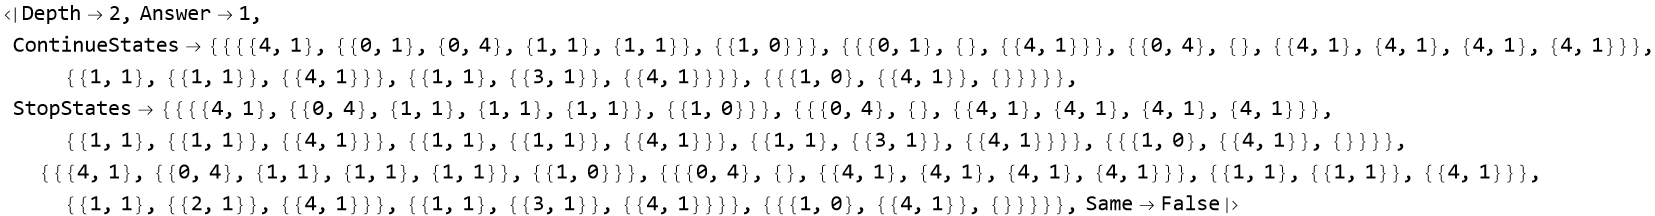

In [99]:
RawPair64[2, 1]

In [100]:
pairs64=Flatten[
Table[
RawPair64[d, a],
{d,{2, 5, 9, 15}},
{a, 1, 4}
],
1
];
{
Length[pairs64],
Count[Lookup[pairs64, "Same"], True],
Count[Lookup[pairs64, "Same"], False]
}

{16, 0, 16}

In [102]:
cStates64=Join@@Lookup[
pairs64,
"ContinueStates"
];
sStates64=Join@@Lookup[
pairs64,
"StopStates"
];
states64=DeleteDuplicates[
Join[
cStates64,
sStates64
]
];
{
Length[cStates64],
Length[sStates64],
Length[states64]
}

{16, 32, 8}

Dataset[{<|StateID -> 1, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 2, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 3, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 4, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 5, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 6, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 7, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 8, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{StateID, ContinueCases, StopCases, Conflict}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 8], <||>]
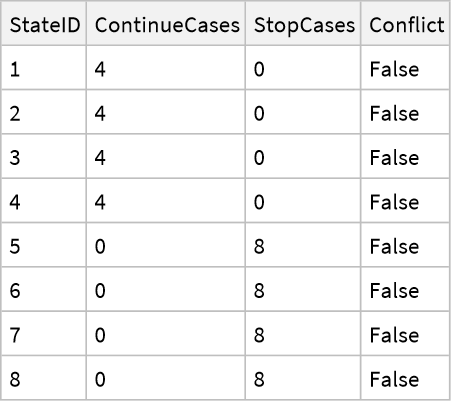

In [106]:
auditStates64=Table[
Module[{cc, ss},
cc=Count[
pairs64,
x_ /; MemberQ[
x["ContinueStates"],
st
]
];
ss=Count[
pairs64,
x_ /; MemberQ[
x["StopStates"],
st
]
];
<|
"StateID"->i,
"ContinueCases"->cc,
"StopCases"->ss,
"Conflict"->TrueQ[
cc>0 && ss>0
]
|>
],
{i, Length[states64]},
{st,{states64[[i]]}}
];
auditStates64=Flatten[
auditStates64
];
Dataset[auditStates64]

In [109]:
cert64=<|
"Stage"->"S64",
"Grammar"->"SharedMerge",
"Radius"->2,
"Pairs"->Length[pairs64],
"PairDifferent"->Count[
Lookup[pairs64, "Same"],
False
],
"PairSame"->Count[
Lookup[pairs64, "Same"],
True
],
"StateTypes"->Length[states64],
"ConflictingStates"->Count[
Lookup[auditStates64, "Conflict"],
True
],
"PureContinueStates"->Count[
auditStates64,
x_ /;
x["ContinueCases"]>0 &&
x["StopCases"]==0
],
"PureStopStates"->Count[
auditStates64,
x_ /;
x["StopCases"] >0 &&
x["ContinueCases"] ==0
]
|>;
Dataset[{cert64}]

Dataset[{<|Stage -> S64, Grammar -> SharedMerge, Radius -> 2, Pairs -> 16, 
 
>     PairDifferent -> 16, PairSame -> 0, StateTypes -> 8, ConflictingStates -> 0, 
 
>     PureContinueStates -> 4, PureStopStates -> 4|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, Radius, Pairs, PairDifferent, 
 
>      PairSame, StateTypes, ConflictingStates, PureContinueStates, PureStopStates}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 1], <||>]

In [111]:
ClearAll[Rows69];
Rows69[g_String , ds_List]:=Flatten[
Table[
Module[{c},
c=If[
g==="S59",
Case59[d, a, t],
Case63[g, d, a, t]
];
<|
"Grammar"->g,
"Depth"->d,
"Answer"->a,
"Target"->t,
"States"->DecisionStates64[c, 2]
|>
],
{d, ds},
{a, 1, 4},
{t,{"Continue", "Stop"}}
],
2
];

In [113]:
rtest69=Rows69["S59",{2}];
{
Length[rtest69],
AssociationQ[First[rtest69]],
Keys[First[rtest69]]
}

{8, True, {Grammar, Depth, Answer, Target, States}}

In [115]:
trainS5969=Rows69[
"S59",
{2, 5}
];
trainChain69=Rows69[
"ChainIn",
{2, 5}
];
train69=Join[
trainS5969,
trainChain69
];
heldS5969=Rows69[
"S59",
{9, 15}
];
heldChain69=Rows69[
"ChainIn",
{9, 15}
];
merge69=Rows69[
"SharedMerge",
{2, 5, 9, 15}
];
{
Length[trainS5969],
Length[trainChain69],
Length[train69],
Length[heldS5969],
Length[heldChain69],
Length[merge69]
}

{16, 16, 32, 16, 16, 32}

In [122]:
ClearAll[EncodeRows69];
EncodeRows69[
data_List,
p_List ,
k_Integer
]:=Module[{rec},
rec[s_]:=rec[s] =If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[
s[[1]]+2 s[[2]],
k
],
Module[{z, ps, cs},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
1+Mod[
p[[1]]+
p[[2]](z-1) +
p[[3]] * Total[ps-1] +
p[[4]] * Total[cs-1] +
p[[5]] * Total[(ps-1)^ 2] +
p[[6]] * Total[(cs-1)^ 2],
k
]
]
];
Map[
Function[row,
<|
"Grammar"->row["Grammar"],
"Depth"->row["Depth"],
"Answer"->row["Answer"],
"Target"->row["Target"],
"Codes"->DeleteDuplicates[
rec/@row["States"]
]
|>
],
data
]
];

In [124]:
e69=EncodeRows69[
train69,
{0, 0,-1,-1,-1, 0},
5
];
{
Length[e69],
And@@(
ListQ[#]&/@Lookup[e69, "Codes"]
),
Min[
Flatten[Lookup[e69, "Codes"]]
],
Max[
Flatten[Lookup[e69, "Codes"]]
]
}

{32, True, 1, 4}

In [126]:
ClearAll[BestStatic69];
BestStatic69[
p_List ,
k_Integer
]:=Module[
{rows, truth, pols, scores, pred, mx, bp},
rows=EncodeRows69[
train69,
p,
k
];
truth=
Boole[# ==="Continue"]&/@
Lookup[rows, "Target"];
pols=Subsets[
Range[k]
];
scores=Table[
pred=Map[
Function[row,
Boole[
AnyTrue[
row["Codes"],
Function[z,
MemberQ[pol, z]
]
]
]
],
rows
];
Total[
MapThread[
Function[{a, b},
Boole[SameQ[a, b]]
],
{pred, truth}
]
],
{pol, pols}
];
mx=Max[scores];
bp=First@SortBy[
Pick[
pols,
scores,
mx
],
Length
];
<|
"K"->k,
"Params"->p,
"BestPassed"->mx,
"Policy"->bp
|>
];

In [128]:
q69=BestStatic69[
{0, 0,-1,-1,-1, 0},
5
];
q69

<|K -> 5, Params -> {0, 0, -1, -1, -1, 0}, BestPassed -> 32, Policy -> {1, 3}|>

In [130]:
pars69=Tuples[
{-1, 0, 1},
6
];
chunks69=Partition[
pars69,
UpTo[81]
];
{
Length[pars69],
Length[chunks69],
Length/@chunks69
}

{729, 9, {81, 81, 81, 81, 81, 81, 81, 81, 81}}

KeyDrop::invrl: The argument SearchChunk69[{{-1, -1, -1, -1, -1, -1}, {-1, -1, -1, -1, -1, 0}, {-1, -1, -1, -1, -1, 1}, {-1, -1, -1, -1, 0, -1}, {-1, -1, -1, -1, 0, 0}, {-1, -1, -1, -1, 0, 1}, {-1, -1, -1, -1, 1, -1}, {-1, -1, -1, -1, 1, 0}, {-1, -1, -1, -1, 1, 1}, {-1, -1, -1, 0, -1, -1}, {-1, -1, -1, 0, -1, 0}, {-1, -1, -1, 0, -1, 1}, {-1, -1, -1, 0, 0, -1}, {-1, -1, -1, 0, 0, 0}, {-1, -1, -1, 0, 0, 1}, {-1, -1, -1, 0, 1, -1}, {-1, -1, -1, 0, 1, 0}, {-1, -1, -1, 0, 1, 1}, {-1, -1, -1, 1, -1, -1}, {-1, -1, -1, 1, -1, 0}, {-1, -1, -1, 1, -1, 1}, {-1, -1, -1, 1, 0, -1}, {-1, -1, -1, 1, 0, 0}, {-1, -1, -1, 1, 0, 1}, {-1, -1, -1, 1, 1, -1}, {-1, -1, -1, 1, 1, 0}, {-1, -1, -1, 1, 1, 1}, {-1, -1, 0, -1, -1, -1}, {-1, -1, 0, -1, -1, 0}, {-1, -1, 0, -1, -1, 1}, {-1, -1, 0, -1, 0, -1}, {-1, -1, 0, -1, 0, 0}, {-1, -1, 0, -1, 0, 1}, {-1, -1, 0, -1, 1, -1}, {-1, -1, 0, -1, 1, 0}, {-1, -1, 0, -1, 1, 1}, {-1, -1, 0, 0, -1, -1}, {-1, -1, 0, 0, -1, 0}, {-1, -1, 0, 0, -1, 1}, {-1, -1, 0, 0, 0, -1}, {-1, -1, 0, 0, 0, 0}, {-1, -1, 0, 0, 0, 1}, {-1, -1, 0, 0, 1, -1}, {-1, -1, 0, 0, 1, 0}, {-1, -1, 0, 0, 1, 1}, {-1, -1, 0, 1, -1, -1}, {-1, -1, 0, 1, -1, 0}, {-1, -1, 0, 1, -1, 1}, {-1, -1, 0, 1, 0, -1}, {-1, -1, 0, 1, 0, 0}, {-1, -1, 0, 1, 0, 1}, {-1, -1, 0, 1, 1, -1}, {-1, -1, 0, 1, 1, 0}, {-1, -1, 0, 1, 1, 1}, {-1, -1, 1, -1, -1, -1}, {-1, -1, 1, -1, -1, 0}, {-1, -1, 1, -1, -1, 1}, {-1, -1, 1, -1, 0, -1}, {-1, -1, 1, -1, 0, 0}, {-1, -1, 1, -1, 0, 1}, {-1, -1, 1, -1, 1, -1}, {-1, -1, 1, -1, 1, 0}, {-1, -1, 1, -1, 1, 1}, {-1, -1, 1, 0, -1, -1}, {-1, -1, 1, 0, -1, 0}, {-1, -1, 1, 0, -1, 1}, {-1, -1, 1, 0, 0, -1}, {-1, -1, 1, 0, 0, 0}, {-1, -1, 1, 0, 0, 1}, {-1, -1, 1, 0, 1, -1}, {-1, -1, 1, 0, 1, 0}, {-1, -1, 1, 0, 1, 1}, {-1, -1, 1, 1, -1, -1}, {-1, -1, 1, 1, -1, 0}, {-1, -1, 1, 1, -1, 1}, {-1, -1, 1, 1, 0, -1}, {-1, -1, 1, 1, 0, 0}, {-1, -1, 1, 1, 0, 1}, {-1, -1, 1, 1, 1, -1}, {-1, -1, 1, 1, 1, 0}, {-1, -1, 1, 1, 1, 1}}, 5] is not a valid Association or a list of rules.

KeyDrop[SearchChunk69[{{-1, -1, -1, -1, -1, -1}, {-1, -1, -1, -1, -1, 0}, 
 
>     {-1, -1, -1, -1, -1, 1}, {-1, -1, -1, -1, 0, -1}, {-1, -1, -1, -1, 0, 0}, 
 
>     {-1, -1, -1, -1, 0, 1}, {-1, -1, -1, -1, 1, -1}, {-1, -1, -1, -1, 1, 0}, 
 
>     {-1, -1, -1, -1, 1, 1}, {-1, -1, -1, 0, -1, -1}, {-1, -1, -1, 0, -1, 0}, 
 
>     {-1, -1, -1, 0, -1, 1}, {-1, -1, -1, 0, 0, -1}, {-1, -1, -1, 0, 0, 0}, 
 
>     {-1, -1, -1, 0, 0, 1}, {-1, -1, -1, 0, 1, -1}, {-1, -1, -1, 0, 1, 0}, 
 
>     {-1, -1, -1, 0, 1, 1}, {-1, -1, -1, 1, -1, -1}, {-1, -1, -1, 1, -1, 0}, 
 
>     {-1, -1, -1, 1, -1, 1}, {-1, -1, -1, 1, 0, -1}, {-1, -1, -1, 1, 0, 0}, 
 
>     {-1, -1, -1, 1, 0, 1}, {-1, -1, -1, 1, 1, -1}, {-1, -1, -1, 1, 1, 0}, 
 
>     {-1, -1, -1, 1, 1, 1}, {-1, -1, 0, -1, -1, -1}, {-1, -1, 0, -1, -1, 0}, 
 
>     {-1, -1, 0, -1, -1, 1}, {-1, -1, 0, -1, 0, -1}, {-1, -1, 0, -1, 0, 0}, 
 
>     {-1, -1, 0, -1, 0, 1}, {-1, -1, 0, -1, 1, -1}, {-1, -1, 0, -1, 1, 0}, 
 
>     {-1, -1, 0, -1, 1, 1}, {-1, -1, 0, 0, -1, -1}, {-1, -1, 0, 0, -1, 0}, 
 
>     {-1, -1, 0, 0, -1, 1}, {-1, -1, 0, 0, 0, -1}, {-1, -1, 0, 0, 0, 0}, 
 
>     {-1, -1, 0, 0, 0, 1}, {-1, -1, 0, 0, 1, -1}, {-1, -1, 0, 0, 1, 0}, 
 
>     {-1, -1, 0, 0, 1, 1}, {-1, -1, 0, 1, -1, -1}, {-1, -1, 0, 1, -1, 0}, 
 
>     {-1, -1, 0, 1, -1, 1}, {-1, -1, 0, 1, 0, -1}, {-1, -1, 0, 1, 0, 0}, 
 
>     {-1, -1, 0, 1, 0, 1}, {-1, -1, 0, 1, 1, -1}, {-1, -1, 0, 1, 1, 0}, 
 
>     {-1, -1, 0, 1, 1, 1}, {-1, -1, 1, -1, -1, -1}, {-1, -1, 1, -1, -1, 0}, 
 
>     {-1, -1, 1, -1, -1, 1}, {-1, -1, 1, -1, 0, -1}, {-1, -1, 1, -1, 0, 0}, 
 
>     {-1, -1, 1, -1, 0, 1}, {-1, -1, 1, -1, 1, -1}, {-1, -1, 1, -1, 1, 0}, 
 
>     {-1, -1, 1, -1, 1, 1}, {-1, -1, 1, 0, -1, -1}, {-1, -1, 1, 0, -1, 0}, 
 
>     {-1, -1, 1, 0, -1, 1}, {-1, -1, 1, 0, 0, -1}, {-1, -1, 1, 0, 0, 0}, 
 
>     {-1, -1, 1, 0, 0, 1}, {-1, -1, 1, 0, 1, -1}, {-1, -1, 1, 0, 1, 0}, 
 
>     {-1, -1, 1, 0, 1, 1}, {-1, -1, 1, 1, -1, -1}, {-1, -1, 1, 1, -1, 0}, 
 
>     {-1, -1, 1, 1, -1, 1}, {-1, -1, 1, 1, 0, -1}, {-1, -1, 1, 1, 0, 0}, 
 
>     {-1, -1, 1, 1, 0, 1}, {-1, -1, 1, 1, 1, -1}, {-1, -1, 1, 1, 1, 0}, 
 
>     {-1, -1, 1, 1, 1, 1}}, 5], Results]
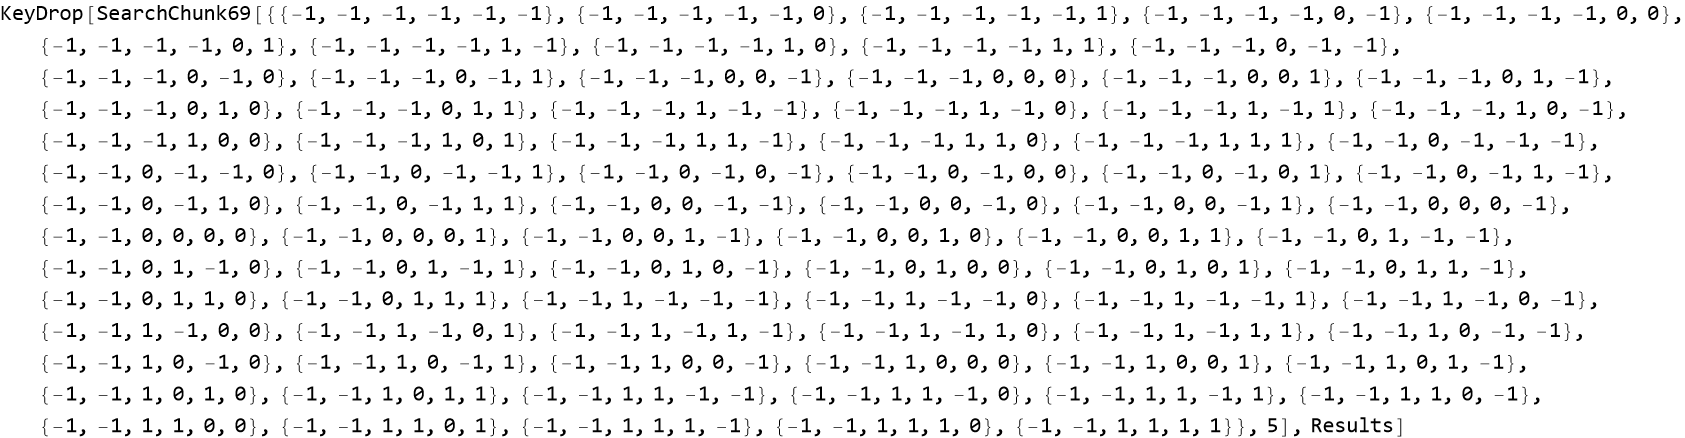

In [133]:
r69A=SearchChunk69[
chunks69[[1]],
5
];
KeyDrop[
r69A,
"Results"
]

In [135]:
{
Length[DownValues[SearchChunk69]],
Head[r69A]
}

{0, SearchChunk69}

In [136]:
ClearAll[SearchChunk69];
SearchChunk69[pp_List , k_Integer]:=Module[
{r, best, perfect},
r=Map[
Function[p,
BestStatic69[p, k]
],
pp
];
best=Max[
Lookup[r, "BestPassed"]
];
perfect=Count[
r,
x_ /; x["BestPassed"]==32
];
<|
"Encoders"->Length[r],
"BestPassed"->best,
"Perfect"->perfect,
"Results"->r
|>
];

In [138]:
testChunk69=SearchChunk69[
Take[pars69, 2],
5
];
{
AssociationQ[testChunk69],
testChunk69["Encoders"],
IntegerQ[testChunk69["BestPassed"]],
IntegerQ[testChunk69["Perfect"]],
Length[testChunk69["Results"]]
}

{True, 2, True, True, 2}

In [140]:
Length[DownValues[SearchChunk69]]

1

In [141]:
r69A=SearchChunk69[
chunks69[[1]],
5
];

In [142]:
{
AssociationQ[r69A],
r69A["Encoders"],
r69A["BestPassed"],
r69A["Perfect"]
}

{True, 81, 32, 16}

In [143]:
KeyDrop[r69A, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 16|>

In [144]:
r69B=SearchChunk69[chunks69[[2]], 5];
KeyDrop[r69B,"Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [146]:
r69C=SearchChunk69[chunks69[[3]], 5];
KeyDrop[r69C, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 9|>

In [148]:
r69D=SearchChunk69[chunks69[[4]], 5];
KeyDrop[r69D, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 11|>

In [150]:
r69E=SearchChunk69[chunks69[[5]], 5];
KeyDrop[r69E, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 13|>

In [152]:
r69F=SearchChunk69[chunks69[[6]], 5];
KeyDrop[r69F, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 9|>

In [154]:
r69G=SearchChunk69[chunks69[[7]], 5];
KeyDrop[r69G, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [156]:
r69H=SearchChunk69[chunks69[[8]], 5];
KeyDrop[r69H, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 14|>

In [158]:
r69I=SearchChunk69[chunks69[[9]], 5];
KeyDrop[r69I, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [160]:
{
r69A["Encoders"],
r69A["BestPassed"],
r69A["Perfect"]
}

{81, 32, 16}

In [161]:
blocks69= {
r69A, r69B, r69C,
r69D, r69E, r69F,
r69G, r69H, r69I
};
all69=Join@@Lookup[
blocks69,
"Results"
];
bestScore69=Max[
Lookup[
all69,
"BestPassed"
]
];
perfect69=Select[
all69,
#["BestPassed"]==32 &
];
cert69A=<|
"Stage"->"S69A",
"EncodersTested"->Length[all69],
"BestPassed"->bestScore69,
"PerfectEncoders"->Length[perfect69],
"ScoreDistribution"->Counts[
Lookup[
all69,
"BestPassed"
]
]
|>;
Dataset[{cert69A}]

Dataset[{<|Stage -> S69A, EncodersTested -> 729, BestPassed -> 32, 
 
>     PerfectEncoders -> 108, ScoreDistribution -> 
 
>      <|28 -> 82, 32 -> 108, 26 -> 160, 16 -> 362, 30 -> 17|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, EncodersTested, BestPassed, 
 
>      PerfectEncoders, ScoreDistribution}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 5]}], 1], <||>]

In [167]:
ClearAll[StaticScore69];
StaticScore69[
m_Association ,
data_List
]:=Module[
{rows, truth, pred},
rows=EncodeRows69[
data,
m["Params"],
m["K"]
];
truth=
Boole[# ==="Continue"]&/@
Lookup[rows, "Target"];
pred=Map[
Function[row,
Boole[
AnyTrue[
row["Codes"],
Function[z,
MemberQ[m["Policy"], z]
]
]
]
],
rows
];
Total[
MapThread[
Function[{a, b},
Boole[SameQ[a, b]]
],
{pred, truth}
]
]
];

In [169]:
{
StaticScore69[q69, train69],
StaticScore69[q69, heldS5969],
StaticScore69[q69, heldChain69],
StaticScore69[q69, merge69]
}

{32, 16, 16, 24}

In [170]:
perfectChunks69C=Partition[
perfect69,
UpTo[18]
];
Length/@perfectChunks69C

{18, 18, 18, 18, 18, 18}

In [172]:
s69C1=StaticScore69[#, merge69]&/@perfectChunks69C[[1]];
{
Length[s69C1],
Min[s69C1],
Max[s69C1]
}

{18, 4, 32}

In [174]:
s69C2=StaticScore69[#, merge69]&/@perfectChunks69C[[2]];
{
Length[s69C2],
Min[s69C2],
Max[s69C2]
}

{18, 0, 28}

In [176]:
s69C3=StaticScore69[#, merge69]&/@perfectChunks69C[[3]];
{
Length[s69C3],
Min[s69C3],
Max[s69C3]
}

{18, 4, 32}

In [178]:
s69C4=StaticScore69[#, merge69]&/@perfectChunks69C[[4]];
{
Length[s69C4],
Min[s69C4],
Max[s69C4]
}

{18, 4, 24}

In [180]:
s69C5=StaticScore69[#, merge69]&/@perfectChunks69C[[5]];
{
Length[s69C5],
Min[s69C5],
Max[s69C5]
}

{18, 0, 24}

In [182]:
s69C6=StaticScore69[#, merge69]&/@perfectChunks69C[[6]];
{
Length[s69C6],
Min[s69C6],
Max[s69C6]
}

{18, 4, 32}

In [184]:
scores69C=Join[
s69C1, s69C2, s69C3,
s69C4, s69C5, s69C6
];
cert69C=<|
"Stage"->"S69C",
"TrainingPerfectEncoders"->Length[perfect69],
"SharedMergeBest"->Max[scores69C],
"SharedMergeWorst"->Min[scores69C],
"SharedMergeMean"->N[Mean[scores69C]],
"SharedMergeDistribution"->Counts[scores69C],
"PerfectTransferEncoders"->Count[
scores69C,
32
],
"AboveChanceEncoders"->Count[
scores69C,
x_ /; x>16
],
"AtChanceEncoders"->Count[
scores69C,
16
]
|>;
Dataset[{cert69C}]

Dataset[{<|Stage -> S69C, TrainingPerfectEncoders -> 108, SharedMergeBest -> 32, 
 
>     SharedMergeWorst -> 0, SharedMergeMean -> 15.1111, 
 
>     SharedMergeDistribution -> 
 
>      <|32 -> 5, 4 -> 11, 8 -> 9, 12 -> 31, 24 -> 17, 16 -> 27, 20 -> 3, 28 -> 3, 
 
>       0 -> 2|>, PerfectTransferEncoders -> 5, AboveChanceEncoders -> 28, 
 
>     AtChanceEncoders -> 27|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, 
 
>      TrainingPerfectEncoders, SharedMergeBest, SharedMergeWorst, SharedMergeMean, 
 
>      SharedMergeDistribution, PerfectTransferEncoders, AboveChanceEncoders, 
 
>      AtChanceEncoders}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 9], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 1]
 
>    , <||>]

In [187]:
idxPerfectTransfer69=Flatten@
Position[scores69C, 32];
transferPerfect69=
perfect69[[idxPerfectTransfer69]];
{
Length[transferPerfect69],
Lookup[transferPerfect69, "Params"],
Lookup[transferPerfect69, "Policy"]
}

{5, {{-1, -1, -1, -1, -1, 0}, {0, -1, 1, -1, -1, 0}, {0, -1, 1, 0, -1, -1}, 
 
>    {1, 1, 1, -1, 1, 1}, {1, 1, 1, 1, 1, -1}}, {{1, 4}, {1, 4}, {2, 4}, {2, 5}, {1, 3}}}

In [190]:
Dataset[
MapIndexed[
Function[{m, idx},
<|
"ID"->First[idx],
"Params"->m["Params"],
"Policy"->m["Policy"],
"TrainPassed"->m["BestPassed"],
"SharedMergePassed"->32
|>
],
transferPerfect69
]
]

Dataset[{<|ID -> 1, Params -> {-1, -1, -1, -1, -1, 0}, Policy -> {1, 4}, 
 
>     TrainPassed -> 32, SharedMergePassed -> 32|>, 
 
>    <|ID -> 2, Params -> {0, -1, 1, -1, -1, 0}, Policy -> {1, 4}, TrainPassed -> 32, 
 
>     SharedMergePassed -> 32|>, <|ID -> 3, Params -> {0, -1, 1, 0, -1, -1}, 
 
>     Policy -> {2, 4}, TrainPassed -> 32, SharedMergePassed -> 32|>, 
 
>    <|ID -> 4, Params -> {1, 1, 1, -1, 1, 1}, Policy -> {2, 5}, TrainPassed -> 32, 
 
>     SharedMergePassed -> 32|>, <|ID -> 5, Params -> {1, 1, 1, 1, 1, -1}, 
 
>     Policy -> {1, 3}, TrainPassed -> 32, SharedMergePassed -> 32|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{ID, Params, Policy, TrainPassed, 
 
>      SharedMergePassed}, {TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [191]:
paramsTP69=Lookup[
transferPerfect69,
"Params"
];
Table[
<|
"Position"->j,
"Values"->paramsTP69[[All, j]],
"Counts"->Counts[
paramsTP69[[All, j]]
]
|>,
{j, 6}
]//Dataset

Dataset[{<|Position -> 1, Values -> {-1, 0, 0, 1, 1}, 
 
>     Counts -> <|-1 -> 1, 0 -> 2, 1 -> 2|>|>, 
 
>    <|Position -> 2, Values -> {-1, -1, -1, 1, 1}, Counts -> <|-1 -> 3, 1 -> 2|>|>, 
 
>    <|Position -> 3, Values -> {-1, 1, 1, 1, 1}, Counts -> <|-1 -> 1, 1 -> 4|>|>, 
 
>    <|Position -> 4, Values -> {-1, -1, 0, -1, 1}, 
 
>     Counts -> <|-1 -> 3, 0 -> 1, 1 -> 1|>|>, 
 
>    <|Position -> 5, Values -> {-1, -1, -1, 1, 1}, Counts -> <|-1 -> 3, 1 -> 2|>|>, 
 
>    <|Position -> 6, Values -> {0, 0, -1, 1, -1}, 
 
>     Counts -> <|0 -> 2, -1 -> 2, 1 -> 1|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Position, Values, Counts}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 5], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength]}], 6], <||>]

In [193]:
Counts[
Lookup[
transferPerfect69,
"Policy"
]
]

<|{1, 4} -> 2, {2, 4} -> 1, {2, 5} -> 1, {1, 3} -> 1|>

In [194]:
ClearAll[Jaccard70];
Jaccard70[a_List, b_List]:=Module[
{u},
u=Union[a, b];
If[
Length[u]==0,
1.,
N[
Length[Intersection[a, b]] /
Length[u]
]
]
];

In [196]:
{
Jaccard70[{1, 2},{1, 2}],
Jaccard70[{1},{2}],
Jaccard70[{1, 2},{2, 3}]
}

{1., 0., 0.333333}

In [197]:
ClearAll[Consistency70];
Consistency70[m_Association]:=Module[
{s59, ch, pairs, exact, jac, selExact, selJac, pol},
s59=EncodeRows69[
trainS5969,
m["Params"],
m["K"]
];
ch=EncodeRows69[
trainChain69,
m["Params"],
m["K"]
];
pol=m["Policy"];
pairs=MapThread[
Function[{x, y},
<|
"Exact"->SameQ[
Sort[x["Codes"]],
Sort[y["Codes"]]
],
"Jaccard"->Jaccard70[
x["Codes"],
y["Codes"]
],
"SelectedExact"->SameQ[
Sort[Intersection[x["Codes"], pol]],
Sort[Intersection[y["Codes"], pol]]
],
"SelectedJaccard"->Jaccard70[
Intersection[x["Codes"], pol],
Intersection[y["Codes"], pol]
]
|>
],
{s59, ch}
];
<|
"ExactPairs"->Count[
Lookup[pairs, "Exact"],
True
],
"MeanJaccard"->Mean[
Lookup[pairs, "Jaccard"]
],
"SelectedExactPairs"->Count[
Lookup[pairs, "SelectedExact"],
True
],
"SelectedMeanJaccard"->Mean[
Lookup[pairs, "SelectedJaccard"]
]
|>
];

In [199]:
test70=Consistency70[
First[perfect69]
];
test70

<|ExactPairs -> 8, MeanJaccard -> 0.5, SelectedExactPairs -> 12, 
 
>   SelectedMeanJaccard -> 0.75|>

In [201]:
cons70=Consistency70/@perfect69;
Length[cons70]

108

In [203]:
rows70=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"ExactPairs"->c["ExactPairs"],
"MeanJaccard"->c["MeanJaccard"],
"SelectedExactPairs"->
c["SelectedExactPairs"],
"SelectedMeanJaccard"->
c["SelectedMeanJaccard"],
"SharedMergeScore"->s,
"TransferPerfect"->Boole[
s==32
]
|>
],
{perfect69, cons70, scores69C}
];
Length[rows70]

108

In [205]:
corr70=<|
"ExactCorrelation"->
Correlation[
N[Lookup[rows70, "ExactPairs"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"JaccardCorrelation"->
Correlation[
N[Lookup[rows70, "MeanJaccard"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"SelectedExactCorrelation"->
Correlation[
N[Lookup[rows70, "SelectedExactPairs"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"SelectedJaccardCorrelation"->
Correlation[
N[Lookup[rows70, "SelectedMeanJaccard"]],
N[Lookup[rows70, "SharedMergeScore"]]
]
|>;
corr70

<|ExactCorrelation -> -0.0492993, JaccardCorrelation -> -0.0492993, 
 
>   SelectedExactCorrelation -> -0.0492993, SelectedJaccardCorrelation -> -0.0492993|>

In [207]:
good70=Select[
rows70,
#["TransferPerfect"]==1 &
];
bad70=Select[
rows70,
#["TransferPerfect"]==0 &
];
summary70=<|
"PerfectTransferCount"->
Length[good70],
"OtherCount"->
Length[bad70],
"PerfectMeanExact"->
N@Mean[
Lookup[good70, "ExactPairs"]
],
"OtherMeanExact"->
N@Mean[
Lookup[bad70, "ExactPairs"]
],
"PerfectMeanJaccard"->
N@Mean[
Lookup[good70, "MeanJaccard"]
],
"OtherMeanJaccard"->
N@Mean[
Lookup[bad70, "MeanJaccard"]
],
"PerfectSelectedExact"->
N@Mean[
Lookup[good70, "SelectedExactPairs"]
],
"OtherSelectedExact"->
N@Mean[
Lookup[bad70, "SelectedExactPairs"]
],
"PerfectSelectedJaccard"->
N@Mean[
Lookup[good70, "SelectedMeanJaccard"]
],
"OtherSelectedJaccard"->
N@Mean[
Lookup[bad70, "SelectedMeanJaccard"]
]
|>;
Dataset[{summary70}]

Dataset[{<|PerfectTransferCount -> 5, OtherCount -> 103, PerfectMeanExact -> 8., 
 
>     OtherMeanExact -> 10.4078, PerfectMeanJaccard -> 0.5, 
 
>     OtherMeanJaccard -> 0.650485, PerfectSelectedExact -> 12., 
 
>     OtherSelectedExact -> 13.2039, PerfectSelectedJaccard -> 0.75, 
 
>     OtherSelectedJaccard -> 0.825243|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{PerfectTransferCount, OtherCount, 
 
>      PerfectMeanExact, OtherMeanExact, PerfectMeanJaccard, OtherMeanJaccard, 
 
>      PerfectSelectedExact, OtherSelectedExact, PerfectSelectedJaccard, 
 
>      OtherSelectedJaccard}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real]}], 1], <||>]

In [211]:
rank70=Reverse@SortBy[
Range[Length[perfect69]],
Function[i,
{
cons70[[i, "SelectedMeanJaccard"]],
cons70[[i, "MeanJaccard"]],
cons70[[i, "SelectedExactPairs"]],
cons70[[i, "ExactPairs"]]
}
]
];
topIdx70=First[rank70];
selected70=perfect69[[topIdx70]];
<|
"Index"->topIdx70,
"Params"->selected70["Params"],
"Policy"->selected70["Policy"],
"Consistency"->cons70[[topIdx70]]
|>

<|Index -> 96, Params -> {1, 0, 1, 1, 1, 1}, Policy -> {5}, 
 
>   Consistency -> 
 
>    <|ExactPairs -> 16, MeanJaccard -> 1., SelectedExactPairs -> 16, 
 
>     SelectedMeanJaccard -> 1.|>|>

In [215]:
<|
"SelectedIndex"->topIdx70,
"SharedMergeScore"->
scores69C[[topIdx70]],
"WasPerfectTransfer"->
TrueQ[
scores69C[[topIdx70]] ==32
]
|>

<|SelectedIndex -> 96, SharedMergeScore -> 24, WasPerfectTransfer -> False|>

In [216]:
ClearAll[AllowedPerms70B];
AllowedPerms70B[
pol_List ,
k_Integer
]:=Select[
Permutations[Range[k]],
Function[pm,
And@@Table[
SameQ[
MemberQ[pol, z],
MemberQ[pol, pm[[z]]]
],
{z, k}
]
]
];

In [218]:
{
Length[AllowedPerms70B[{1, 3}, 5]],
Length[AllowedPerms70B[{5}, 5]]
}

{12, 24}

In [219]:
ClearAll[ApplyPerm70B];
ApplyPerm70B[
codes_List,
pm_List
]:=Sort[
pm[[#]]&/@codes
];

In [221]:
ApplyPerm70B[
{1, 3, 5},
{3, 2, 1, 5, 4}
]

{1, 3, 4}

In [222]:
ClearAll[AlignConsistency70B];
AlignConsistency70B[
m_Association
]:=Module[
{s59, ch, pol, k, perms, res, best,
pm, a, b, sa, sb, ex, jac, sex, sjac},
s59=EncodeRows69[
trainS5969,
m["Params"],
m["K"]
];
ch=EncodeRows69[
trainChain69,
m["Params"],
m["K"]
];
pol=m["Policy"];
k=m["K"];
perms=AllowedPerms70B[
pol,
k
];
res=Table[
ex=0;
jac=0.;
sex=0;
sjac=0.;
Do[
a=Sort[
Lookup[
s59[[i]],
"Codes"
]
];
b=ApplyPerm70B[
Lookup[
ch[[i]],
"Codes"
],
pm
];
sa=Intersection[
a,
pol
];
sb=Intersection[
b,
pol
];
If[
SameQ[a, b],
ex++
];
jac+=Jaccard70[a, b];
If[
SameQ[sa, sb],
sex++
];
sjac+=Jaccard70[sa, sb],
{i, Length[s59]}
];
<|
"Permutation"->pm,
"ExactPairs"->ex,
"MeanJaccard"->N[
jac/Length[s59]
],
"SelectedExactPairs"->sex,
"SelectedMeanJaccard"->N[
sjac/Length[s59]
]
|>,
{pm, perms}
];
best=Last@SortBy[
res,
Function[r,
{
r["ExactPairs"],
r["MeanJaccard"],
r["SelectedExactPairs"],
r["SelectedMeanJaccard"]
}
]
];
Join[
<|
"AllowedPermutations"->
Length[perms]
|>,
best
]
];

In [224]:
test70B=AlignConsistency70B[
First[perfect69]
];
test70B

<|AllowedPermutations -> 12, Permutation -> {4, 5, 3, 1, 2}, ExactPairs -> 8, 
 
>   MeanJaccard -> 0.5, SelectedExactPairs -> 12, SelectedMeanJaccard -> 0.75|>

In [226]:
align70B=
AlignConsistency70B/@perfect69;
Length[align70B]

108

In [228]:
<|
"ExactDistribution"->
Counts[
Lookup[
align70B,
"ExactPairs"
]
],
"SelectedExactDistribution"->
Counts[
Lookup[
align70B,
"SelectedExactPairs"
]
],
"PerfectAligned"->
Count[
align70B,
x_ /;
x["ExactPairs"] ==16
]
|>

<|ExactDistribution -> <|8 -> 59, 12 -> 22, 16 -> 27|>, 
 
>   SelectedExactDistribution -> <|12 -> 59, 14 -> 22, 16 -> 27|>, PerfectAligned -> 27|>

In [229]:
rows70B=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"AlignedExact"->
c["ExactPairs"],
"AlignedJaccard"->
c["MeanJaccard"],
"AlignedSelectedExact"->
c["SelectedExactPairs"],
"AlignedSelectedJaccard"->
c["SelectedMeanJaccard"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
align70B,
scores69C
}
];
corr70B=<|
"AlignedExactCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedExact"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedJaccardCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedJaccard"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedSelectedExactCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedSelectedExact"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedSelectedJaccardCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedSelectedJaccard"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
]
|>;
corr70Bcorr70C=<|
"PerfectNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"PerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"NearPerfectCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"NearPerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MeanNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MeanNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MinNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MinNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
]
|>;
corr70C

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

General::stop: Further output of Lookup::invrl will be suppressed during this calculation.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

General::stop: Further output of Correlation::vctmat will be suppressed during this calculation.

corr70C

In [233]:
good70B=Select[
rows70B,
#["TransferPerfect"]==1 &
];
bad70B=Select[
rows70B,
#["TransferPerfect"]==0 &
];
summary70B=<|
"PerfectCount"->
Length[good70B],
"OtherCount"->
Length[bad70B],
"PerfectAlignedExact"->
N@Mean[
Lookup[
good70B,
"AlignedExact"
]
],
"OtherAlignedExact"->
N@Mean[
Lookup[
bad70B,
"AlignedExact"
]
],
"PerfectAlignedJaccard"->
N@Mean[
Lookup[
good70B,
"AlignedJaccard"
]
],
"OtherAlignedJaccard"->
N@Mean[
Lookup[
bad70B,
"AlignedJaccard"
]
],
"PerfectSelectedAligned"->
N@Mean[
Lookup[
good70B,
"AlignedSelectedExact"
]
],
"OtherSelectedAligned"->
N@Mean[
Lookup[
bad70B,
"AlignedSelectedExact"
]
]
|>;
Dataset[{summary70B}]

Dataset[{<|PerfectCount -> 5, OtherCount -> 103, PerfectAlignedExact -> 8., 
 
>     OtherAlignedExact -> 10.9515, PerfectAlignedJaccard -> 0.5, 
 
>     OtherAlignedJaccard -> 0.684466, PerfectSelectedAligned -> 12., 
 
>     OtherSelectedAligned -> 13.4757|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{PerfectCount, OtherCount, PerfectAlignedExact, 
 
>      OtherAlignedExact, PerfectAlignedJaccard, OtherAlignedJaccard, 
 
>      PerfectSelectedAligned, OtherSelectedAligned}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real]}], 1], <||>]

In [237]:
rank70B=Reverse@SortBy[
Range[
Length[perfect69]
],
Function[i,
{
align70B[[i, "SelectedExactPairs"]],
align70B[[i, "SelectedMeanJaccard"]],
align70B[[i, "ExactPairs"]],
align70B[[i, "MeanJaccard"]]
}
]
];
topIdx70B=First[
rank70B
];
selected70B=
perfect69[[topIdx70B]];
<|
"Index"->topIdx70B,
"Params"->
selected70B["Params"],
"Policy"->
selected70B["Policy"],
"Alignment"->
align70B[[topIdx70B]]
|>

<|Index -> 96, Params -> {1, 0, 1, 1, 1, 1}, Policy -> {5}, 
 
>   Alignment -> <|AllowedPermutations -> 24, Permutation -> {4, 2, 3, 1, 5}, 
 
>     ExactPairs -> 16, MeanJaccard -> 1., SelectedExactPairs -> 16, 
 
>     SelectedMeanJaccard -> 1.|>|>

In [241]:
<|
"SelectedIndex"->topIdx70B,
"SharedMergeScore"->
scores69C[[topIdx70B]],
"PerfectTransfer"->
TrueQ[
scores69C[[topIdx70B]] ==32
]
|>

<|SelectedIndex -> 96, SharedMergeScore -> 24, PerfectTransfer -> False|>

In [242]:
ClearAll[Key70C];
Key70C[p_List]:=
ToString[p, InputForm];
scoreMap70C=AssociationThread[
Key70C/@Lookup[all69, "Params"],
Lookup[all69, "BestPassed"]
];
{
Length[scoreMap70C],
Min[Values[scoreMap70C]],
Max[Values[scoreMap70C]]
}

{729, 16, 32}

In [246]:
ClearAll[Neighbors70C];
Neighbors70C[p_List]:=
DeleteDuplicates[
Flatten[
Table[
ReplacePart[
p,
j->v
],
{j, Length[p]},
{v, DeleteCases[
{-1, 0, 1},
p[[j]]
]}
],
1
]
];

In [248]:
n70=Neighbors70C[
{0, 0,-1,-1,-1, 0}
];
{
Length[n70],
Length/@n70,
MemberQ[
n70,
{0, 0,-1,-1,-1, 0}
]
}

{12, {6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6}, False}

In [250]:
ClearAll[Flatness70C];
Flatness70C[m_Association]:=Module[
{p, ns, sc},
p=m["Params"];
ns=Neighbors70C[p];
sc=Lookup[
scoreMap70C,
Key70C/@ns
];
<|
"PerfectNeighbors"->Count[
sc,
32
],
"NearPerfectNeighbors"->Count[
sc,
x_ /; x>=30
],
"MeanNeighborScore"->N[
Mean[sc]
],
"MinNeighborScore"->Min[sc],
"MaxNeighborScore"->Max[sc],
"NeighborScores"->sc
|>
];

In [252]:
Flatness70C[
First[perfect69]
]

<|PerfectNeighbors -> 4, NearPerfectNeighbors -> 4, MeanNeighborScore -> 27.1667, 
 
>   MinNeighborScore -> 16, MaxNeighborScore -> 32, 
 
>   NeighborScores -> {28, 32, 28, 28, 16, 32, 16, 32, 26, 28, 28, 32}|>

In [253]:
flat70C=
Flatness70C/@perfect69;
Length[flat70C]

108

In [255]:
<|
"PerfectNeighborDistribution"->
Counts[
Lookup[
flat70C,
"PerfectNeighbors"
]
],
"NearPerfectDistribution"->
Counts[
Lookup[
flat70C,
"NearPerfectNeighbors"
]
],
"MeanScoreRange"-> {
Min[
Lookup[
flat70C,
"MeanNeighborScore"
]
],
Max[
Lookup[
flat70C,
"MeanNeighborScore"
]
]
}
|>

<|PerfectNeighborDistribution -> 
 
>    <|4 -> 18, 3 -> 23, 6 -> 12, 5 -> 18, 7 -> 4, 2 -> 25, 1 -> 7, 0 -> 1|>, 
 
>   NearPerfectDistribution -> 
 
>    <|4 -> 19, 6 -> 10, 7 -> 9, 5 -> 27, 2 -> 22, 3 -> 17, 1 -> 3, 9 -> 1|>, 
 
>   MeanScoreRange -> {22.1667, 29.1667}|>

In [256]:
rows70C=MapThread[
Function[{m, f, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"PerfectNeighbors"->
f["PerfectNeighbors"],
"NearPerfectNeighbors"->
f["NearPerfectNeighbors"],
"MeanNeighborScore"->
f["MeanNeighborScore"],
"MinNeighborScore"->
f["MinNeighborScore"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
flat70C,
scores69C
}
];

Correlation::zerosd: The standard deviation for one or more vectors or matrix columns is zero.

<|PerfectNeighborCorrelation -> 0.016037, NearPerfectCorrelation -> -0.0178667, 
 
>   MeanNeighborCorrelation -> -0.0769909, 
 
>   MinNeighborCorrelation -> 
 
>    Correlation[{16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16.}, 
 
>     {32., 4., 8., 12., 4., 8., 24., 24., 16., 16., 16., 12., 12., 16., 4., 4., 12., 
 
>      8., 24., 20., 16., 24., 24., 8., 4., 12., 12., 16., 16., 4., 20., 12., 28., 0., 
 
>      28., 12., 12., 12., 8., 12., 12., 32., 4., 32., 16., 12., 28., 24., 16., 24., 
 
>      12., 8., 12., 8., 16., 24., 24., 12., 16., 24., 16., 16., 4., 16., 12., 12., 24., 
 
>      12., 12., 4., 12., 24., 16., 4., 12., 0., 16., 24., 12., 12., 12., 12., 20., 24., 
 
>      12., 16., 16., 12., 16., 16., 16., 12., 16., 16., 16., 24., 16., 16., 8., 16., 
 
>      24., 8., 4., 12., 32., 12., 32., 24.}]|>
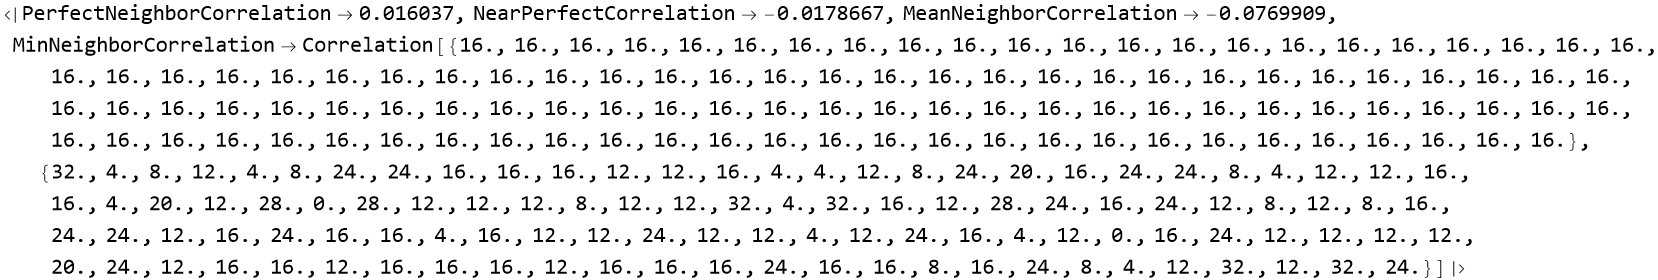

In [257]:
corr70C=<|
"PerfectNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"PerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"NearPerfectCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"NearPerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MeanNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MeanNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MinNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MinNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
]
|>;
corr70C

In [259]:
ClearAll[SafeCorr70]; SafeCorr70[a_List, b_List]:=
Module[{x=N[a], y=N[b]}, If[StandardDeviation[x]==0||StandardDeviation[y]==0,
Missing["ConstantVector"], Correlation[x, y]]];

Dataset[{<|Stage -> S70C, PerfectNeighborCorrelation -> 0.016037, 
 
>     NearPerfectCorrelation -> -0.0178667, MeanNeighborCorrelation -> -0.0769909, 
 
>     MinNeighborCorrelation -> Missing[ConstantVector], 
 
>     MinNeighborDistribution -> <|16 -> 108|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, PerfectNeighborCorrelation, 
 
>      NearPerfectCorrelation, MeanNeighborCorrelation, MinNeighborCorrelation, 
 
>      MinNeighborDistribution}, {TypeSystem`Atom[String], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`UnknownType, 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 1]}], 1], 
 
>   <||>]
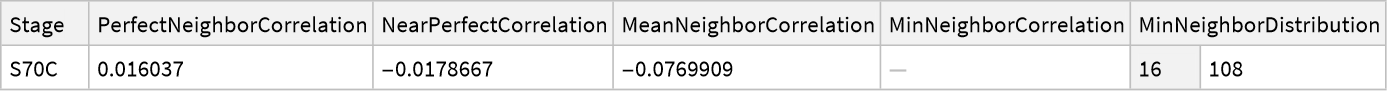

In [260]:
cert70C=<|
"Stage"->"S70C",
"PerfectNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "PerfectNeighbors"],
Lookup[rows70C, "SharedMergeScore"]
],
"NearPerfectCorrelation"->
SafeCorr70[
Lookup[rows70C, "NearPerfectNeighbors"],
Lookup[rows70C, "SharedMergeScore"]
],
"MeanNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "MeanNeighborScore"],
Lookup[rows70C, "SharedMergeScore"]
],
"MinNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "MinNeighborScore"],
Lookup[rows70C, "SharedMergeScore"]
],
"MinNeighborDistribution"->
Counts[
Lookup[rows70C, "MinNeighborScore"]
]
|>;
Dataset[{cert70C}]

In [262]:
ClearAll[CodeState70D];
CodeState70D[
s_,
p_List ,
k_Integer
]:=Module[{rec},
rec[x_ ]:=rec[x] =If[
MatchQ[x,{_Integer,_Integer}],
1+Mod[
x[[1]]+2 x[[2]],
k
],
Module[{z, ps, cs},
z=rec[x[[1]]];
ps=rec/@x[[2]];
cs=rec/@x[[3]];
1+Mod[
p[[1]]+
p[[2]](z-1) +
p[[3]] * Total[ps-1] +
p[[4]] * Total[cs-1] +
p[[5]] * Total[(ps-1)^ 2] +
p[[6]] * Total[(cs-1)^ 2],
k
]
]
];
rec[s]
];

In [264]:
{
Length[states64],
CodeState70D[
states64[[1]],
perfect69[[1, "Params"]],
5
]
}

{8, 4}

In [265]:
stateRows70D=MapThread[
Function[{st, a},
<|
"StateID"->a["StateID"],
"State"->st,
"Target"->
If[
a["ContinueCases"]>0,
"Continue",
"Stop"
]
|>
],
{
states64,
auditStates64
}
];
Dataset[
KeyDrop[
stateRows70D,
"State"
]
]

Dataset[{<|StateID -> 1, Target -> Continue|>, <|StateID -> 2, Target -> Continue|>, 
 
>    <|StateID -> 3, Target -> Continue|>, <|StateID -> 4, Target -> Continue|>, 
 
>    <|StateID -> 5, Target -> Stop|>, <|StateID -> 6, Target -> Stop|>, 
 
>    <|StateID -> 7, Target -> Stop|>, <|StateID -> 8, Target -> Stop|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{StateID, Target}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Enumeration[Continue, 
 
>        Stop]]}], 8], <||>]

In [267]:
ClearAll[Collision70D];
Collision70D[m_Association]:=Module[
{codes, cCodes, sCodes, shared,
pol, cGood, sGood},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@states64;
cCodes=DeleteDuplicates[
Pick[
codes,
Lookup[stateRows70D, "Target"],
"Continue"
]
];
sCodes=DeleteDuplicates[
Pick[
codes,
Lookup[stateRows70D, "Target"],
"Stop"
]
];
shared=Intersection[
cCodes,
sCodes
];
pol=m["Policy"];
cGood=Count[
Take[codes, 4],
z_ /; MemberQ[pol, z]
];
sGood=Count[
Drop[codes, 4],
z_ /;!MemberQ[pol, z]
];
<|
"Codes"->codes,
"ContinueCodes"->cCodes,
"StopCodes"->sCodes,
"SharedCodes"->shared,
"SemanticCollisions"->Length[shared],
"ContinueCorrectStates"->cGood,
"StopCorrectStates"->sGood,
"StateCorrect"->cGood+sGood
|>
];

In [269]:
Collision70D[
perfect69[[96]]
]

<|Codes -> {3, 5, 5, 3, 1, 3, 3, 1}, ContinueCodes -> {3, 5}, StopCodes -> {1, 3}, 
 
>   SharedCodes -> {3}, SemanticCollisions -> 1, ContinueCorrectStates -> 2, 
 
>   StopCorrectStates -> 4, StateCorrect -> 6|>

In [270]:
goodCollision70D=
Collision70D/@transferPerfect69;
goodTable70D=MapIndexed[
Function[{x, i},
Join[
<|"ID"->First[i]|>,
KeyDrop[x, "Codes"]
]
],
goodCollision70D
];
Dataset[goodTable70D]

Dataset[{<|ID -> 1, ContinueCodes -> {4, 1}, StopCodes -> {5, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 2, ContinueCodes -> {1, 4}, StopCodes -> {2, 5}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 3, ContinueCodes -> {4, 2}, StopCodes -> {5, 3}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 4, ContinueCodes -> {2, 5}, StopCodes -> {3, 1}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 5, ContinueCodes -> {3, 1}, StopCodes -> {4, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>}, TypeSystem`Vector[TypeSystem`Struct[{ID, ContinueCodes, 
 
>      StopCodes, SharedCodes, SemanticCollisions, ContinueCorrectStates, 
 
>      StopCorrectStates, StateCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`UnknownType, TypeSystem`AnyLength], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [273]:
ClearAll[Collision70D];
Collision70D[m_Association]:=Module[
{codes, labels, ci, si, cCodes, sCodes,
shared, pol, cGood, sGood},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@states64;
labels=Lookup[
stateRows70D,
"Target"
];
ci=Flatten@Position[
labels,
"Continue"
];
si=Flatten@Position[
labels,
"Stop"
];
cCodes=DeleteDuplicates[
codes[[ci]]
];
sCodes=DeleteDuplicates[
codes[[si]]
];
shared=Intersection[
cCodes,
sCodes
];
pol=m["Policy"];
cGood=Count[
codes[[ci]],
z_ /; MemberQ[pol, z]
];
sGood=Count[
codes[[si]],
z_ /;!MemberQ[pol, z]
];
<|
"Codes"->codes,
"ContinueCodes"->cCodes,
"StopCodes"->sCodes,
"SharedCodes"->shared,
"SemanticCollisions"->Length[shared],
"ContinueCorrectStates"->cGood,
"StopCorrectStates"->sGood,
"StateCorrect"->cGood+sGood
|>
];

In [275]:
Collision70D[
perfect69[[96]]
]

<|Codes -> {3, 5, 5, 3, 1, 3, 3, 1}, ContinueCodes -> {3, 5}, StopCodes -> {1, 3}, 
 
>   SharedCodes -> {3}, SemanticCollisions -> 1, ContinueCorrectStates -> 2, 
 
>   StopCorrectStates -> 4, StateCorrect -> 6|>

In [276]:
goodCollision70D=
Collision70D/@transferPerfect69;
goodTable70D=MapIndexed[
Function[{x, i},
Join[
<|"ID"->First[i]|>,
KeyDrop[x, "Codes"]
]
],
goodCollision70D
];
Dataset[goodTable70D]

Dataset[{<|ID -> 1, ContinueCodes -> {4, 1}, StopCodes -> {5, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 2, ContinueCodes -> {1, 4}, StopCodes -> {2, 5}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 3, ContinueCodes -> {4, 2}, StopCodes -> {5, 3}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 4, ContinueCodes -> {2, 5}, StopCodes -> {3, 1}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 5, ContinueCodes -> {3, 1}, StopCodes -> {4, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>}, TypeSystem`Vector[TypeSystem`Struct[{ID, ContinueCodes, 
 
>      StopCodes, SharedCodes, SemanticCollisions, ContinueCorrectStates, 
 
>      StopCorrectStates, StateCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`UnknownType, TypeSystem`AnyLength], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [279]:
collision70D=
Collision70D/@perfect69;
rows70D=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"SemanticCollisions"->
c["SemanticCollisions"],
"StateCorrect"->
c["StateCorrect"],
"ContinueCorrect"->
c["ContinueCorrectStates"],
"StopCorrect"->
c["StopCorrectStates"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
collision70D,
scores69C
}
];
Length[rows70D]

108

In [282]:
goodRows70D=Select[
rows70D,
#["TransferPerfect"]==1 &
];
otherRows70D=Select[
rows70D,
#["TransferPerfect"]==0 &
];
summary70D=<|
"Cases"->Length[rows70D],
"CollisionDistribution"->
Counts[
Lookup[
rows70D,
"SemanticCollisions"
]
],
"StateCorrectDistribution"->
Counts[
Lookup[
rows70D,
"StateCorrect"
]
],
"PerfectTransferCount"->
Length[goodRows70D],
"PerfectTransferCollisions"->
Counts[
Lookup[
goodRows70D,
"SemanticCollisions"
]
],
"PerfectTransferStateCorrect"->
Counts[
Lookup[
goodRows70D,
"StateCorrect"
]
],
"OtherCollisionDistribution"->
Counts[
Lookup[
otherRows70D,
"SemanticCollisions"
]
]
|>;
Dataset[{summary70D}]

Dataset[{<|Cases -> 108, CollisionDistribution -> <|0 -> 34, 1 -> 48, 2 -> 26|>, 
 
>     StateCorrectDistribution -> 
 
>      <|8 -> 5, 2 -> 16, 4 -> 54, 3 -> 4, 6 -> 20, 7 -> 3, 0 -> 2, 5 -> 4|>, 
 
>     PerfectTransferCount -> 5, PerfectTransferCollisions -> <|0 -> 5|>, 
 
>     PerfectTransferStateCorrect -> <|8 -> 5|>, 
 
>     OtherCollisionDistribution -> <|1 -> 48, 0 -> 29, 2 -> 26|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Cases, CollisionDistribution, 
 
>      StateCorrectDistribution, PerfectTransferCount, PerfectTransferCollisions, 
 
>      PerfectTransferStateCorrect, OtherCollisionDistribution}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 8], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 3]}], 1], 
 
>   <||>]

In [286]:
collisionScore70D=Counts[
Map[
Function[x,
{
x["SemanticCollisions"],
x["SharedMergeScore"]
}
],
rows70D
]
];
collisionScore70D

<|{0, 32} -> 5, {1, 4} -> 3, {1, 8} -> 7, {0, 12} -> 7, {0, 4} -> 7, {0, 24} -> 7, 
 
>   {1, 16} -> 18, {2, 16} -> 6, {0, 16} -> 3, {2, 12} -> 17, {1, 24} -> 10, 
 
>   {1, 20} -> 3, {1, 12} -> 7, {0, 28} -> 3, {0, 0} -> 2, {2, 8} -> 2, {2, 4} -> 1|>

In [288]:
correctScore70D=Counts[
Map[
Function[x,
{
x["StateCorrect"],
x["SharedMergeScore"]
}
],
rows70D
]
];
correctScore70D

<|{8, 32} -> 5, {2, 4} -> 11, {2, 8} -> 5, {4, 12} -> 31, {3, 8} -> 4, {6, 24} -> 17, 
 
>   {4, 16} -> 23, {6, 20} -> 3, {7, 28} -> 3, {0, 0} -> 2, {5, 16} -> 4|>

In [290]:
cert70D=<|
"Stage"->"S70D",
"Encoders"->Length[rows70D],
"TransferPerfect"->
Count[
rows70D,
x_ /; x["SharedMergeScore"]==32
],
"StateCorrect8"->
Count[
rows70D,
x_ /; x["StateCorrect"]==8
],
"StateCorrect8AndPerfect"->
Count[
rows70D,
x_ /;
x["StateCorrect"]==8 &&
x["SharedMergeScore"]==32
],
"PerfectWithStateError"->
Count[
rows70D,
x_ /;
x["StateCorrect"] <8 &&
x["SharedMergeScore"]==32
],
"CollisionFree"->
Count[
rows70D,
x_ /; x["SemanticCollisions"] ==0
],
"CollisionFreeButNotPerfect"->
Count[
rows70D,
x_ /;
x["SemanticCollisions"] ==0 &&
x["SharedMergeScore"] <32
],
"StateCorrectCorrelation"->
SafeCorr70[
Lookup[rows70D, "StateCorrect"],
Lookup[rows70D, "SharedMergeScore"]
],
"CollisionCorrelation"->
SafeCorr70[
Lookup[rows70D, "SemanticCollisions"],
Lookup[rows70D, "SharedMergeScore"]
]
|>;
Dataset[{cert70D}]

Dataset[{<|Stage -> S70D, Encoders -> 108, TransferPerfect -> 5, StateCorrect8 -> 5, 
 
>     StateCorrect8AndPerfect -> 5, PerfectWithStateError -> 0, CollisionFree -> 34, 
 
>     CollisionFreeButNotPerfect -> 29, StateCorrectCorrelation -> 0.967414, 
 
>     CollisionCorrelation -> -0.220886|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Encoders, TransferPerfect, 
 
>      StateCorrect8, StateCorrect8AndPerfect, PerfectWithStateError, CollisionFree, 
 
>      CollisionFreeButNotPerfect, StateCorrectCorrelation, CollisionCorrelation}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]

In [292]:
ClearAll[TrainRobustness71];
TrainRobustness71[m_Association]:=Module[
{data, pol, rows, cont, stop},
data=Join[
trainS5969,
trainChain69
];
pol=m["Policy"];
rows=Map[
Function[row,
Module[{codes, n, sel},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@row["States"];
n=Length[codes];
sel=Count[
codes,
z_ /; MemberQ[pol, z]
];
<|
"Target"->row["Target"],
"States"->n,
"Selected"->sel,
"Fraction"->
If[n==0, 0., N[sel/n]]
|>
]
],
data
];
cont=Select[
rows,
#["Target"] ==="Continue" &
];
stop=Select[
rows,
#["Target"] ==="Stop" &
];
<|
"ContinueMinSelected"->
Min[Lookup[cont, "Selected"]],
"ContinueMeanSelected"->
N@Mean[Lookup[cont, "Selected"]],
"ContinueMinFraction"->
Min[Lookup[cont, "Fraction"]],
"ContinueMeanFraction"->
N@Mean[Lookup[cont, "Fraction"]],
"ContinueAllSelectedCases"->
Count[
cont,
x_ /; x["Selected"]==x["States"]
],
"StopSelectedTotal"->
Total[Lookup[stop, "Selected"]]
|>
];

In [294]:
test71=TrainRobustness71[
First[perfect69]
];
test71

<|ContinueMinSelected -> 1, ContinueMeanSelected -> 1., ContinueMinFraction -> 1., 
 
>   ContinueMeanFraction -> 1., ContinueAllSelectedCases -> 16, StopSelectedTotal -> 0|>

In [296]:
rob71=
TrainRobustness71/@perfect69;
Length[rob71]

108

In [298]:
<|
"MinSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueMinSelected"
]
],
"MeanSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueMeanSelected"
]
],
"MinFractionDistribution"->
Counts[
Lookup[
rob71,
"ContinueMinFraction"
]
],
"AllSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueAllSelectedCases"
]
],
"StopSelectedDistribution"->
Counts[
Lookup[
rob71,
"StopSelectedTotal"
]
]
|>

<|MinSelectedDistribution -> <|1 -> 108|>, MeanSelectedDistribution -> <|1. -> 108|>, 
 
>   MinFractionDistribution -> <|1. -> 108|>, AllSelectedDistribution -> <|16 -> 108|>, 
 
>   StopSelectedDistribution -> <|0 -> 108|>|>

In [299]:
selected71=First@SortBy[
transferPerfect69,
Function[m,
{
Total[Abs[m["Params"]]],
Length[m["Policy"]],
m["Params"],
m["Policy"]
}
]
];
frozen71=<|
"Params"->selected71["Params"],
"K"->selected71["K"],
"Policy"->selected71["Policy"]
|>;
frozen71

<|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>

In [302]:
ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

In [304]:
p71=ParallelIn71[
Case59[2, 1, "Continue"]
];
{
Head[p71],
Length[p71],
Length[p71[[1]]],
Length[p71[[1, 1]]] >
Length[Case59[2, 1, "Continue"][[1, 1]]]
}

{List, 2, 6, True}

In [306]:
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

In [308]:
testRows71=Flatten[
Table[
<|
"Grammar"->"ParallelIn",
"Depth"->d,
"Answer"->a,
"Target"->t,
"States"->DecisionStates64[
Case71[d, a, t],
2
]
|>,
{d,{2, 5, 9, 15}},
{a, 1, 4},
{t,{"Continue", "Stop"}}
],
2
];
{
Length[testRows71],
Counts[
Lookup[testRows71, "Target"]
]
}

{32, <|Continue -> 16, Stop -> 16|>}

Dataset[{<|Stage -> S71, Topology -> ParallelIn, Cases -> 32, 
 
>     ModelFrozenBeforeTest -> True, SharedMergeUsedAsValidation -> True, 
 
>     ParallelInUsedForSelection -> False, Params -> {0, -1, 1, -1, -1, 0}, 
 
>     Policy -> {1, 4}, Passed -> 32, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Topology, Cases, ModelFrozenBeforeTest, 
 
>      SharedMergeUsedAsValidation, ParallelInUsedForSelection, Params, Policy, Passed, 
 
>      Accuracy}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]
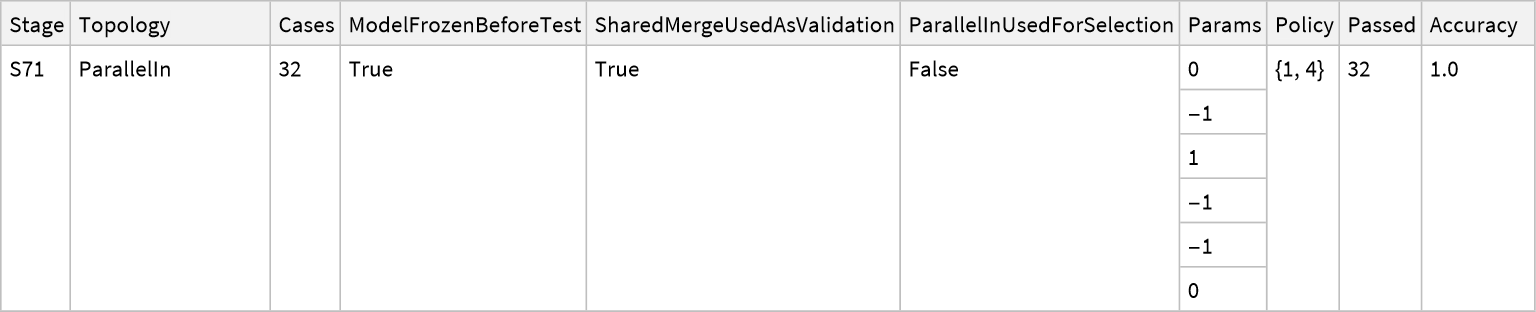

In [310]:
score71=
StaticScore69[
selected71,
testRows71
];
blindCert71=<|
"Stage"->"S71",
"Topology"->"ParallelIn",
"Cases"->32,
"ModelFrozenBeforeTest"->True,
"SharedMergeUsedAsValidation"->True,
"ParallelInUsedForSelection"->False,
"Params"->selected71["Params"],
"Policy"->selected71["Policy"],
"Passed"->score71,
"Accuracy"->N[score71/32]
|>;
Dataset[{blindCert71}]

In [313]:
candidateScores71=
StaticScore69[
#,
testRows71
]&/@transferPerfect69;
<|
"CandidateCount"->Length[candidateScores71],
"Scores"->candidateScores71,
"Distribution"->Counts[candidateScores71],
"PerfectCandidates"->Count[
candidateScores71,
32
]
|>

<|CandidateCount -> 5, Scores -> {24, 32, 32, 16, 16}, 
 
>   Distribution -> <|24 -> 1, 32 -> 2, 16 -> 2|>, PerfectCandidates -> 2|>

## S71 visual summary

Dataset[{<|Stage -> S71, Topology -> ParallelIn, Cases -> 32, 
 
>     ModelFrozenBeforeTest -> True, SharedMergeUsedAsValidation -> True, 
 
>     ParallelInUsedForSelection -> False, Params -> {0, -1, 1, -1, -1, 0}, 
 
>     Policy -> {1, 4}, Passed -> 32, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Topology, Cases, ModelFrozenBeforeTest, 
 
>      SharedMergeUsedAsValidation, ParallelInUsedForSelection, Params, Policy, Passed, 
 
>      Accuracy}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]
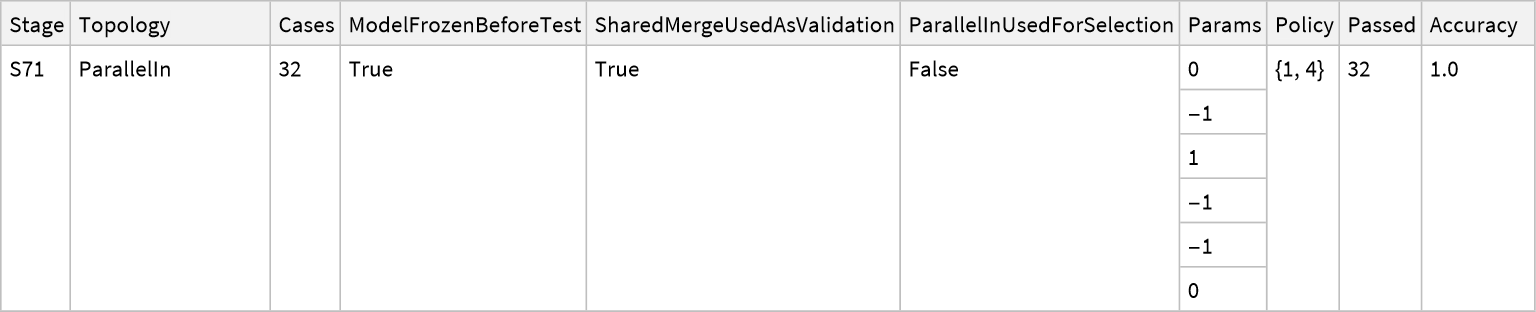

In [319]:
Dataset[{blindCert71}]

-Graphics-
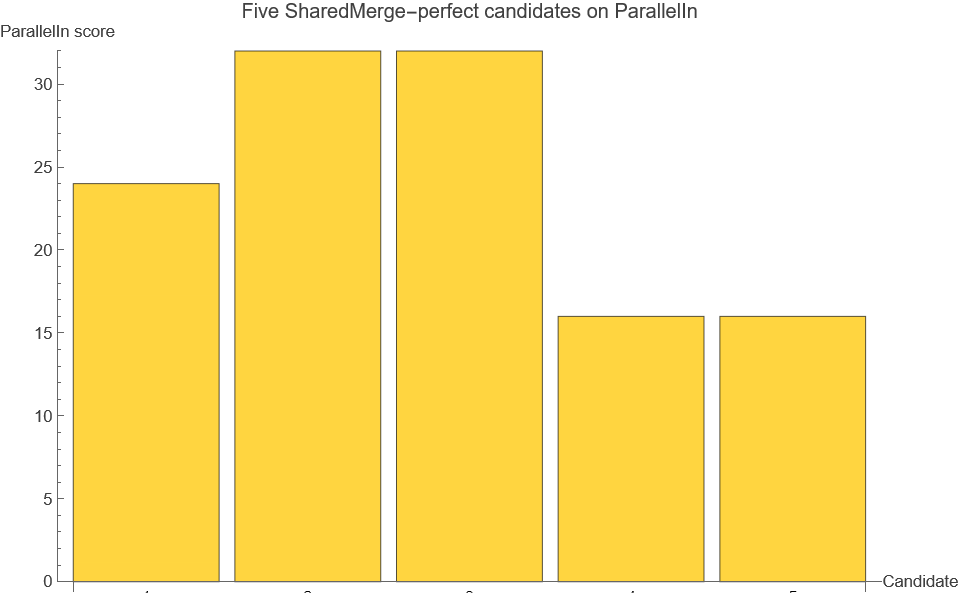

In [320]:
BarChart[
 candidateScores71,
 ChartLabels -> Placed[Range[Length[candidateScores71]], Below],
 PlotRange -> {0, 32},
 AxesLabel -> {"Candidate", "ParallelIn score"},
 PlotLabel -> "Five SharedMerge-perfect candidates on ParallelIn",
 ImageSize -> Large
]

S59 base              ParallelIn blind topology

Graph[<101>, <104>]   Graph[<125>, <140>]
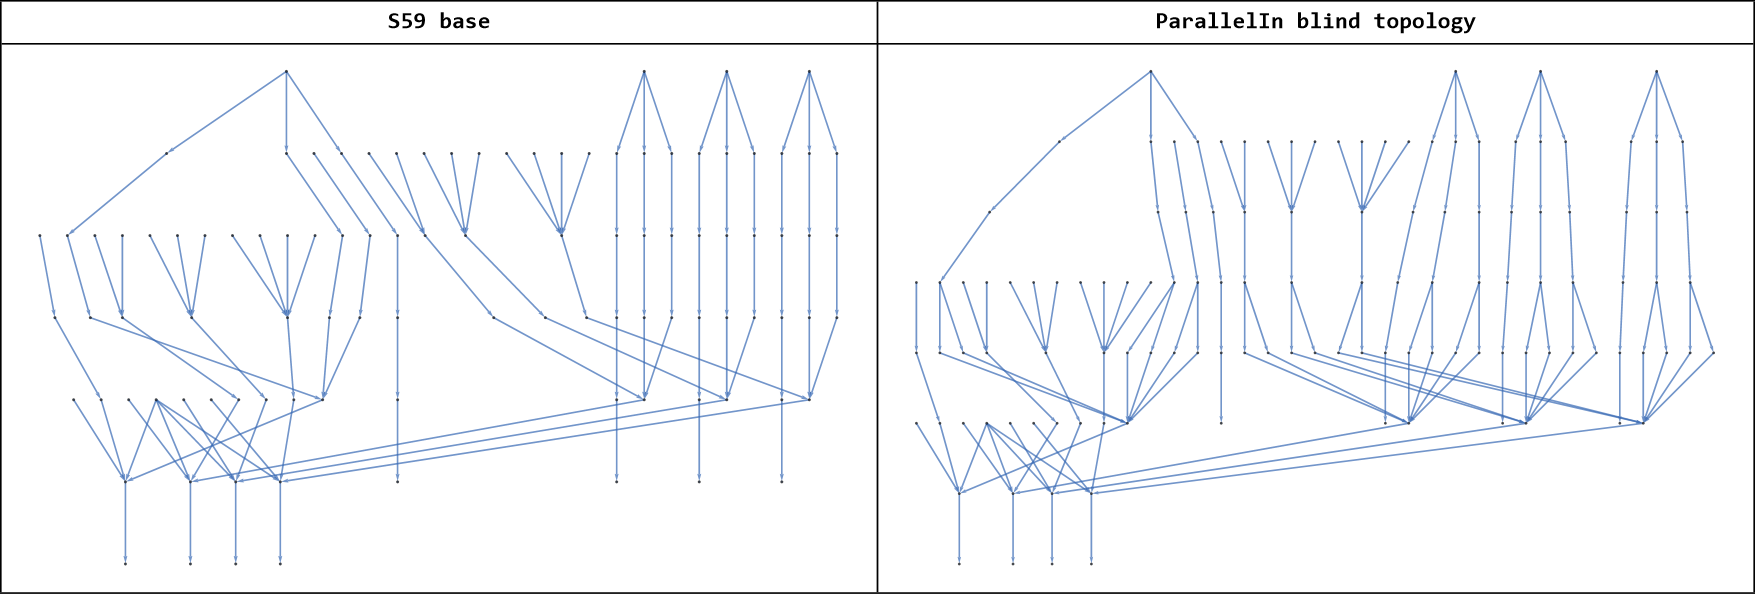

In [321]:
With[{base = Case59[2, 1, "Continue"], parallel = Case71[2, 1, "Continue"]},
 Grid[{
   {Style["S59 base", Bold, 14], Style["ParallelIn blind topology", Bold, 14]},
   {Graph[base[[1, 1]], GraphLayout -> "LayeredDigraphEmbedding", VertexLabels -> None, VertexSize -> Tiny, ImageSize -> 500],
    Graph[parallel[[1, 1]], GraphLayout -> "LayeredDigraphEmbedding", VertexLabels -> None, VertexSize -> Tiny, ImageSize -> 500]}
 }, Frame -> All, Spacings -> {2, 1}]
]

## Frozen model

Do not retune this model inside the S71 checkpoint. Create a separate notebook for S72.

In [326]:
<|"K" -> 5, "Params" -> {0, -1, 1, -1, -1, 0}, "Policy" -> {1, 4}|>

<|K -> 5, Params -> {0, -1, 1, -1, -1, 0}, Policy -> {1, 4}|>

# S72 — Frozen Topology Battery

This protocol was written and frozen before any S72 score was evaluated. The S71 model remains fixed. Run all S71 cells first, then execute the S72 cells in order. Do not edit the topology definitions after viewing scores.

## Pre-registered blind families

- `ParallelOut`: parallel expansion on decision-node outputs.
- `DiamondIn`: each incoming edge splits and reconverges before the decision node.
- `SharedParallelIn`: all parents feed two shared gates before the decision node.

The battery contains 32 cases per family and 96 cases total.

Dataset[{<|Stage -> S72, Name -> FrozenTopologyBattery, 
 
>     ProtocolFrozenBeforeEvaluation -> True, ModelFrozenBeforeEvaluation -> True, 
 
>     Topologies -> {ParallelOut, DiamondIn, SharedParallelIn}, Depths -> {2, 5, 9, 15}, 
 
>     Answers -> {1, 2, 3, 4}, Targets -> {Continue, Stop}, Radius -> 2, 
 
>     CasesPerTopology -> 32, TotalCases -> 96, S72UsedForSelection -> False, 
 
>     RetuningAllowed -> False, ProtocolHash -> 
 
>      9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb, 
 
>     ModelMatchesS71 -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      ProtocolFrozenBeforeEvaluation, ModelFrozenBeforeEvaluation, Topologies, Depths, 
 
>      Answers, Targets, Radius, CasesPerTopology, TotalCases, S72UsedForSelection, 
 
>      RetuningAllowed, ProtocolHash, ModelMatchesS71}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
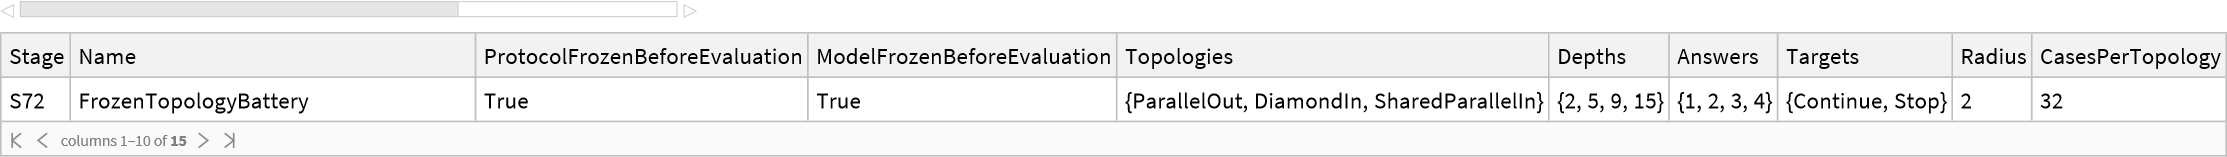

In [335]:
ClearAll["Global`*72"];

frozenModel72=<|
"Params"->{0,-1,1,-1,-1,0},
"K"->5,
"Policy"->{1,4}
|>;

topologies72={
"ParallelOut",
"DiamondIn",
"SharedParallelIn"
};

depths72={2,5,9,15};
answers72=Range[4];
targets72={"Continue","Stop"};

protocol72=<|
"Stage"->"S72",
"Name"->"FrozenTopologyBattery",
"ProtocolFrozenBeforeEvaluation"->True,
"ModelFrozenBeforeEvaluation"->True,
"Model"->frozenModel72,
"Topologies"->topologies72,
"Depths"->depths72,
"Answers"->answers72,
"Targets"->targets72,
"Radius"->2,
"CasesPerTopology"->32,
"TotalCases"->96,
"S72UsedForSelection"->False,
"RetuningAllowed"->False
|>;

protocolHash72=Hash[
Normal[protocol72],
"SHA256",
"HexString"
];

modelLock72=SameQ[
frozenModel72,
frozen71
];

Dataset[{
Join[
KeyDrop[protocol72,"Model"],
<|
"ProtocolHash"->protocolHash72,
"ModelMatchesS71"->modelLock72
|>
]
}]

In [345]:
ClearAll[
ParallelOut72,
DiamondIn72,
SharedParallelIn72,
Case72
];

ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72[
topology_String,
d_Integer,
a_Integer,
t_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[d,a,t]],
"DiamondIn",
DiamondIn72[Case59[d,a,t]],
"SharedParallelIn",
SharedParallelIn72[Case59[d,a,t]],
_,
$Failed
];

Dataset[{<|Topology -> ParallelOut, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 116, EdgeCountIncreased -> True|>, 
 
>    <|Topology -> DiamondIn, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 152, EdgeCountIncreased -> True|>, 
 
>    <|Topology -> SharedParallelIn, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 124, EdgeCountIncreased -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, ShapeOK, MetadataPreserved, 
 
>      AnswerPreserved, DirectedEdgesOnly, EdgeCountBefore, EdgeCountAfter, 
 
>      EdgeCountIncreased}, {TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 3], <||>]
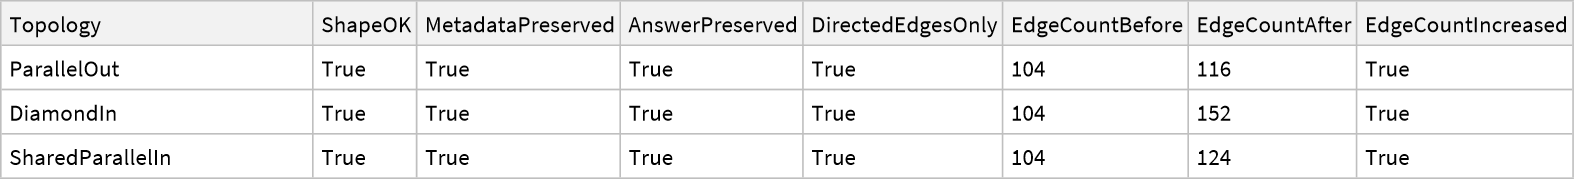

In [350]:
ClearAll[TopologyAudit72];

TopologyAudit72[topology_String]:=Module[
{base,changed,baseEdges,newEdges},
base=Case59[2,1,"Continue"];
changed=Case72[topology,2,1,"Continue"];
baseEdges=base[[1,1]];
newEdges=changed[[1,1]];
<|
"Topology"->topology,
"ShapeOK"->MatchQ[changed,{{_List,_List,_Integer,_List,_List,_List},_Integer}],
"MetadataPreserved"->SameQ[
changed[[1,2;;6]],
base[[1,2;;6]]
],
"AnswerPreserved"->SameQ[changed[[2]],base[[2]]],
"DirectedEdgesOnly"->AllTrue[
newEdges,
MatchQ[#,DirectedEdge[_,_]]&
],
"EdgeCountBefore"->Length[baseEdges],
"EdgeCountAfter"->Length[newEdges],
"EdgeCountIncreased"->Length[newEdges]>Length[baseEdges]
|>
];

audit72=TopologyAudit72/@topologies72;

auditPass72=And@@Flatten[
Lookup[
audit72,
{
"ShapeOK",
"MetadataPreserved",
"AnswerPreserved",
"DirectedEdgesOnly",
"EdgeCountIncreased"
}
]
];

Dataset[audit72]

Dataset[{<|ExpectedCases -> 96, BuiltCases -> 96, 
 
>     CasesByTopology -> <|ParallelOut -> 32, DiamondIn -> 32, SharedParallelIn -> 32|>, 
 
>     CasesByTarget -> <|Continue -> 48, Stop -> 48|>, AuditPassed -> True, 
 
>     ModelLockPassed -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{ExpectedCases, 
 
>      BuiltCases, CasesByTopology, CasesByTarget, AuditPassed, ModelLockPassed}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>         SharedParallelIn]], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>       TypeSystem`Atom[Integer], 2], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
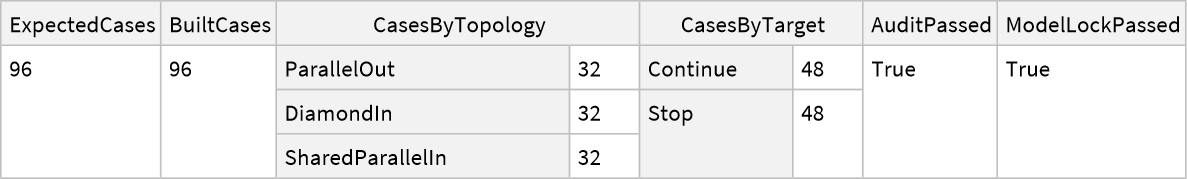

In [355]:
spec72=Tuples[{
topologies72,
depths72,
answers72,
targets72
}];

testRows72=Map[
Function[spec,
<|
"Grammar"->spec[[1]],
"Depth"->spec[[2]],
"Answer"->spec[[3]],
"Target"->spec[[4]],
"States"->DecisionStates64[
Case72@@spec,
protocol72["Radius"]
]
|>
],
spec72
];

caseBuildCert72=<|
"ExpectedCases"->protocol72["TotalCases"],
"BuiltCases"->Length[testRows72],
"CasesByTopology"->Counts[Lookup[testRows72,"Grammar"]],
"CasesByTarget"->Counts[Lookup[testRows72,"Target"]],
"AuditPassed"->auditPass72,
"ModelLockPassed"->modelLock72
|>;

Dataset[{caseBuildCert72}]

In [359]:
encodedRows72=If[
TrueQ[modelLock72]&&TrueQ[auditPass72],
EncodeRows69[
testRows72,
frozenModel72["Params"],
frozenModel72["K"]
],
$Failed
];

caseResults72=If[
ListQ[encodedRows72],
Map[
Function[row,
Module[{prediction},
prediction=If[
AnyTrue[
row["Codes"],
MemberQ[frozenModel72["Policy"],#]&
],
"Continue",
"Stop"
];
Join[
row,
<|
"Prediction"->prediction,
"Passed"->Boole[prediction===row["Target"]]
|>
]
]
],
encodedRows72
],
{}
];

scoresByTopology72=GroupBy[
caseResults72,
# ["Grammar"]&,
Total[Lookup[#,"Passed"]]&
];

scoresByTopologyTarget72=GroupBy[
caseResults72,
{# ["Grammar"],# ["Target"]}&,
Total[Lookup[#,"Passed"]]&
];

scoresByTopologyDepth72=GroupBy[
caseResults72,
{# ["Grammar"],# ["Depth"]}&,
Total[Lookup[#,"Passed"]]&
];

Dataset[{<|Stage -> S72, Name -> FrozenTopologyBattery, 
 
>     ProtocolHash -> 9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb, 
 
>     ProtocolFrozenBeforeEvaluation -> True, ModelFrozenBeforeEvaluation -> True, 
 
>     S72UsedForSelection -> False, RetuningAllowed -> False, 
 
>     Model -> <|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>, 
 
>     Topologies -> {ParallelOut, DiamondIn, SharedParallelIn}, Cases -> 96, 
 
>     ScoresByTopology -> <|ParallelOut -> 8, DiamondIn -> 16, SharedParallelIn -> 28|>, 
 
>     ScoresByTopologyTarget -> 
 
>      <|{ParallelOut, Continue} -> 8, {ParallelOut, Stop} -> 0, 
 
>       {DiamondIn, Continue} -> 0, {DiamondIn, Stop} -> 16, 
 
>       {SharedParallelIn, Continue} -> 16, {SharedParallelIn, Stop} -> 12|>, 
 
>     AllTopologiesPerfect -> False, TotalPassed -> 52, Accuracy -> 0.541667|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, ProtocolHash, 
 
>      ProtocolFrozenBeforeEvaluation, ModelFrozenBeforeEvaluation, S72UsedForSelection, 
 
>      RetuningAllowed, Model, Topologies, Cases, ScoresByTopology, 
 
>      ScoresByTopologyTarget, AllTopologiesPerfect, TotalPassed, Accuracy}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Struct[{Params, K, Policy}, 
 
>       {TypeSystem`Vector[TypeSystem`Atom[Integer], 6], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 2]}], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>         SharedParallelIn]], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Tuple[{TypeSystem`Atom[TypeSystem`Enumeration[
 
>           DiamondIn, ParallelOut, SharedParallelIn]], 
 
>         TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]]}], 
 
>       TypeSystem`Atom[Integer], 6], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 1], <||>]
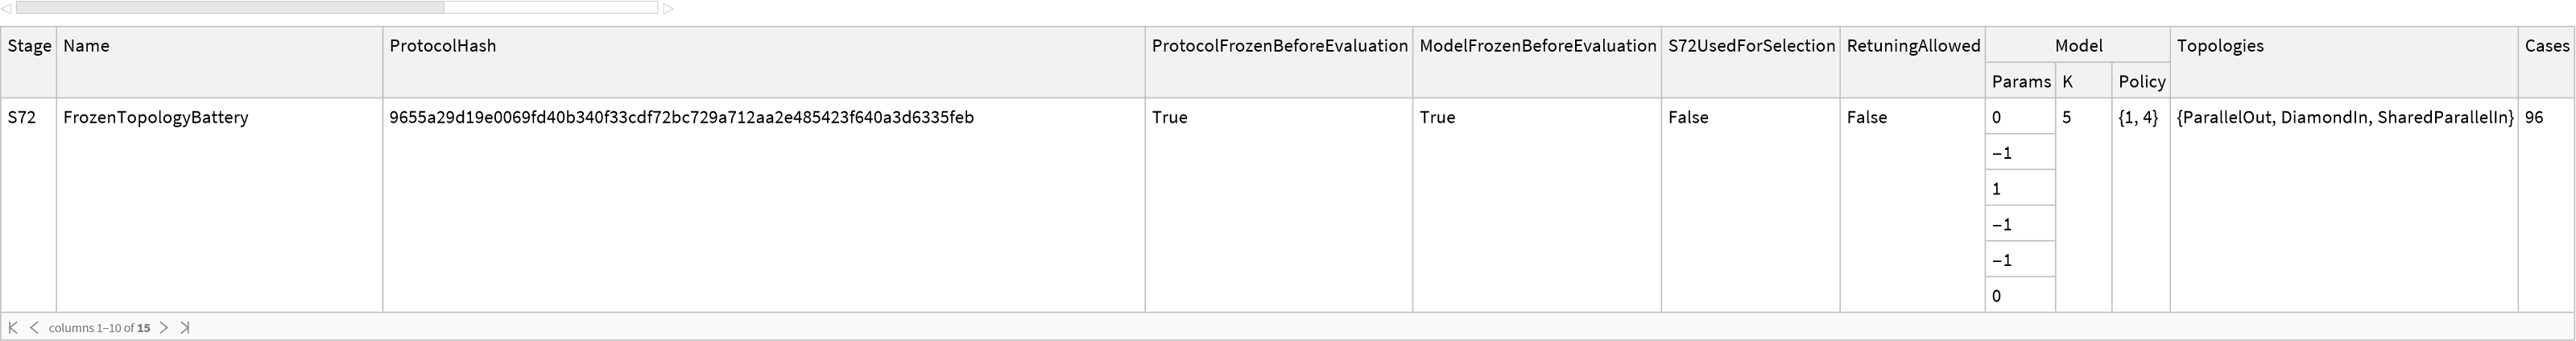

In [364]:
cert72=<|
"Stage"->"S72",
"Name"->"FrozenTopologyBattery",
"ProtocolHash"->protocolHash72,
"ProtocolFrozenBeforeEvaluation"->True,
"ModelFrozenBeforeEvaluation"->True,
"S72UsedForSelection"->False,
"RetuningAllowed"->False,
"Model"->frozenModel72,
"Topologies"->topologies72,
"Cases"->Length[caseResults72],
"ScoresByTopology"->scoresByTopology72,
"ScoresByTopologyTarget"->scoresByTopologyTarget72,
"AllTopologiesPerfect"->And@@MapThread[
SameQ,
{
Lookup[scoresByTopology72,topologies72],
ConstantArray[protocol72["CasesPerTopology"],Length[topologies72]]
}
],
"TotalPassed"->Total[Lookup[caseResults72,"Passed"]],
"Accuracy"->N[Mean[Lookup[caseResults72,"Passed"]]]
|>;

Dataset[{cert72}]

In [366]:
Dataset[
Map[
Function[row,
KeyTake[
row,
{
"Grammar",
"Depth",
"Answer",
"Target",
"Prediction",
"Passed"
}
]
],
Select[caseResults72,# ["Passed"]==0&]
]
]

Dataset[{<|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 3, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 4, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 3, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 4, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 9, Answer -> 1, Target -> Contin

-Graphics-
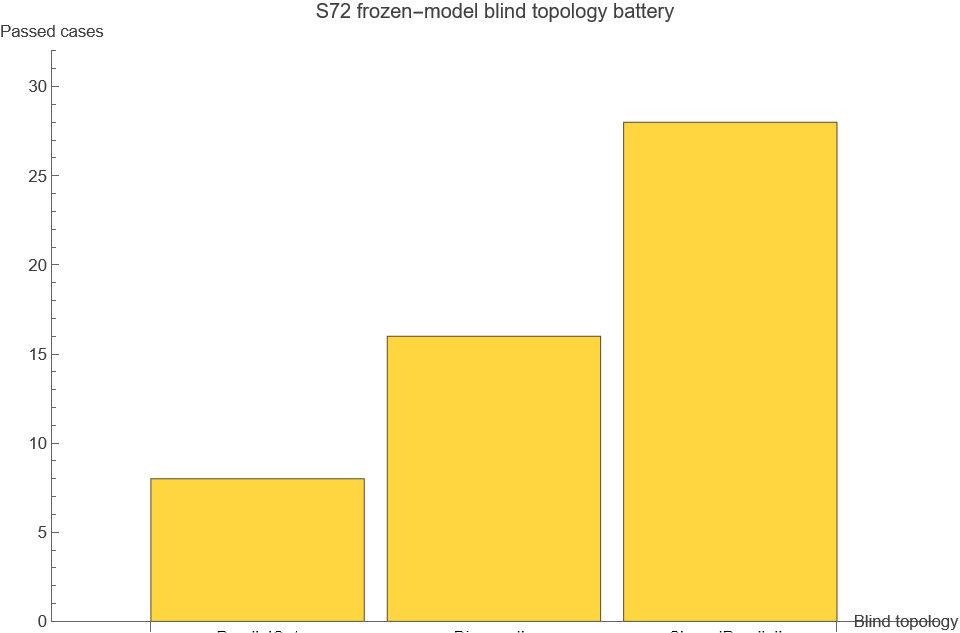

In [367]:
BarChart[
Lookup[scoresByTopology72,topologies72],
ChartLabels->Placed[topologies72,Below],
PlotRange->{0,protocol72["CasesPerTopology"]},
AxesLabel->{"Blind topology","Passed cases"},
PlotLabel->"S72 frozen-model blind topology battery",
ImageSize->Large
]